# Setup 20m x 20m — Lens Antenna 3-TX x 1-RX + Linear TX-User Trajectory

In [1]:
import os
from pathlib import Path

import numpy as np, pandas as pd
import drjit as dr, mitsuba as mi
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as Rot

import sionna.rt as rt
from sionna.rt import (load_scene, PlanarArray, Transmitter, Receiver, PathSolver,
                       AntennaPattern, register_antenna_pattern, ITURadioMaterial,
                       RadioMapSolver, Camera)
from sionna.rt.utils import rotation_matrix

np.set_printoptions(precision=3, suppress=True)


jitc_llvm_init(): LLVM API initialization failed ..


## 1. Antenna pattern loader (farfield HFSS, rotation baked-in)

Adapted from `Setup_20mx20m_9x1_Lens.ipynb`: the rotation (`rot_deg`) is resampled once when the
CSV is read (not per runtime call), cheaper & more consistent.


In [2]:
class HFSSPattern(AntennaPattern):
    def __init__(self, csv_file, freq_ghz=None, param_filters=None,
                 phi_offset_deg=0.0, rot_deg=(0., 0., 0.), polarization="V"):
        super().__init__()
        df = pd.read_csv(csv_file)
        df.columns = [c.strip().strip('"') for c in df.columns]
        df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
        col = lambda key: next(c for c in df.columns if key.lower() in c.lower())
        if freq_ghz is not None:
            df = df[np.isclose(df[col("Freq")], freq_ghz)]
        if param_filters:
            for k, v in param_filters.items():
                df = df[np.isclose(df[col(k)], v)]
        assert len(df) > 0, "No data left after filtering — check freq/parameter"
        th = np.sort(df[col("Theta [")].unique()); ph = np.sort(df[col("Phi [")].unique())
        piv = lambda c: df.pivot_table(index=col("Theta ["), columns=col("Phi ["), values=c).values
        Ctm = np.sqrt(10**(piv(col("GainTheta"))/10.))*np.exp(1j*np.deg2rad(piv(col("rETheta"))))
        Cpm = np.sqrt(10**(piv(col("GainPhi"))/10.)) *np.exp(1j*np.deg2rad(piv(col("rEPhi"))))
        # === rotation via angle, right after the CSV is read (numpy, one-shot) ===
        R = Rot.from_euler("ZYX", np.deg2rad(rot_deg)).as_matrix()
        if not np.allclose(R, np.eye(3)):
            Ctm, Cpm = self._rotate_data(Ctm, Cpm, th, ph, R)
        self._t0, self._dt, self._nt = float(th[0]), float(th[1]-th[0]), len(th)
        self._p0, self._dp, self._np = float(ph[0]), float(ph[1]-ph[0]), len(ph)
        self._phi_off = float(np.deg2rad(phi_offset_deg))
        f32 = lambda x: mi.Float(np.ascontiguousarray(x, np.float32).ravel())
        self._buf = [f32(Ctm.real), f32(Ctm.imag), f32(Cpm.real), f32(Cpm.imag)]
        slants = {"V": [0.], "H": [90.], "VH": [0., 90.], "cross": [-45., 45.]}[polarization]
        self.patterns = [(lambda th_, ph_, z=np.deg2rad(s): self._pattern(th_, ph_, z))
                         for s in slants]

    @staticmethod
    def _rotate_data(Ct, Cp, th_deg, ph_deg, R):
        """Resample the grid pattern: the new pattern in direction v = the old pattern in direction
        u=R^T v, with the field vectors also rotated by R. All numpy, one-shot.
        NB: intentionally without np.matmul/@ — numpy BLAS in this env used to crash (delay-load
        DLL bug)."""
        T, P = np.meshgrid(np.deg2rad(th_deg), np.deg2rad(ph_deg), indexing="ij")
        st, ct = np.sin(T), np.cos(T); sp, cp = np.sin(P), np.cos(P)
        vx, vy, vz = st*cp, st*sp, ct
        ux = R[0,0]*vx + R[1,0]*vy + R[2,0]*vz
        uy = R[0,1]*vx + R[1,1]*vy + R[2,1]*vz
        uz = R[0,2]*vx + R[1,2]*vy + R[2,2]*vz
        thc = np.arccos(np.clip(uz, -1., 1.))
        phc = np.arctan2(uy, ux)
        dt = th_deg[1]-th_deg[0]; dp = ph_deg[1]-ph_deg[0]; nper = len(ph_deg)-1.0
        ft = np.clip((np.rad2deg(thc)-th_deg[0])/dt, 0., len(th_deg)-1.001)
        fp = (np.rad2deg(phc)-ph_deg[0])/dp
        fp = fp - np.floor(fp/nper)*nper
        i0 = np.floor(ft).astype(int); j0 = np.floor(fp).astype(int)
        wt = ft-i0; wp = fp-j0
        samp = lambda A: ((1-wt)*(1-wp)*A[i0,j0] + (1-wt)*wp*A[i0,j0+1]
                        +  wt*(1-wp)*A[i0+1,j0] +  wt*wp*A[i0+1,j0+1])
        Cts, Cps = samp(Ct), samp(Cp)
        sthc, cthc = np.sin(thc), np.cos(thc); sphc, cphc = np.sin(phc), np.cos(phc)
        ex = Cts*cthc*cphc - Cps*sphc
        ey = Cts*cthc*sphc + Cps*cphc
        ez = -Cts*sthc
        Ex = R[0,0]*ex + R[0,1]*ey + R[0,2]*ez
        Ey = R[1,0]*ex + R[1,1]*ey + R[1,2]*ez
        Ez = R[2,0]*ex + R[2,1]*ey + R[2,2]*ez
        Ct_new = Ex*ct*cp + Ey*ct*sp - Ez*st
        Cp_new = -Ex*sp + Ey*cp
        return Ct_new, Cp_new

    def _pattern(self, theta, phi, zeta=0.0):
        ft = dr.clip((theta*180.0/dr.pi - self._t0)/self._dt, 0.0, self._nt-1.001)
        nint = self._np - 1.0
        fp = ((phi - self._phi_off)*180.0/dr.pi - self._p0)/self._dp
        fp = fp - dr.floor(fp/nint)*nint
        i0 = mi.Int32(dr.floor(ft)); j0 = mi.Int32(dr.floor(fp))
        wt = ft - mi.Float(i0);      wp = fp - mi.Float(j0)
        idx = [i0*self._np+j0, i0*self._np+j0+1, (i0+1)*self._np+j0, (i0+1)*self._np+j0+1]
        w = [(1-wt)*(1-wp), (1-wt)*wp, wt*(1-wp), wt*wp]
        v = [sum(wi*dr.gather(mi.Float, bb, ix) for wi, ix in zip(w, idx)) for bb in self._buf]
        Ctr, Cti, Cpr, Cpi = v
        cz, sz = float(np.cos(zeta)), float(np.sin(zeta))
        return (mi.Complex2f(cz*Ctr - sz*Cpr, cz*Cti - sz*Cpi),
                mi.Complex2f(sz*Ctr + cz*Cpr, sz*Cti + cz*Cpi))


def make_hfss_factory(csv_file, **kw):
    def factory(*, polarization="V", polarization_model=None):
        return HFSSPattern(csv_file, polarization=polarization, **kw)
    return factory


## 2. Orientation utilities (world-frame Euler angle, Sionna convention)


In [3]:
def R_of(o):
    return np.array(rotation_matrix(mi.Point3f(*[float(v) for v in o]))).reshape(3, 3)

def angles_from_matrix(R):
    return [float(v) for v in Rot.from_matrix(R).as_euler("ZYX")]

_AX = {"x": np.array([1., 0., 0.]), "y": np.array([0., 1., 0.]), "z": np.array([0., 0., 1.])}

def rotate_antenna(orientation, *steps):
    """Rotate the antenna about its own LOCAL axes, in sequence, in degrees.
    Example: rotate_antenna(o, ("y", 20))            -> tilt 20 deg about the antenna's y-axis
             rotate_antenna(o, ("y", 90), ("z", 30)) -> pitch 90 deg then spin 30 deg
    Returns: [alpha, beta, gamma] rad, ready to use as a Sionna orientation."""
    R = R_of(orientation)
    for axis, deg in steps:
        R = R @ Rot.from_rotvec(np.deg2rad(deg) * _AX[axis.lower()]).as_matrix()
    return angles_from_matrix(R)

def antenna_axes(orientation):
    """See where the antenna's x/y/z axes point in the WORLD frame (for sanity-checking)."""
    R = R_of(orientation)
    return {k: np.round(R @ v, 3) for k, v in _AX.items()}

def orientation_point_z(d):
    """Point the LOCAL +z (aperture normal, HFSS frame) toward world direction d. [rad]"""
    d = np.asarray(d, float); d = d / np.linalg.norm(d)
    return [float(np.arctan2(d[1], d[0])),
            float(np.arccos(np.clip(d[2], -1, 1))),
            0.0]

def boresight_world(orientation, v_local):
    """Predict the direction of any local vector after being rotated by orientation."""
    R = np.array(rotation_matrix(mi.Point3f(*orientation))).reshape(3, 3)
    return R @ np.asarray(v_local, float)


## 3. Room scene (20m x 20m x 3m), reused from `Setup_20mx20m_9x9.ipynb`


In [4]:
def generate_room_xml(room_x=20, room_y=20, room_z=3, xml_path="room_20x20.xml"):
    # Generate a Mitsuba XML scene file for an empty rectangular room (meters).
    hx, hy, hz = room_x / 2, room_y / 2, room_z / 2
    xml = f'''
<scene version="3.0.0">
	<integrator type="path" id="elm__0" name="elm__0">
		<integer name="max_depth" value="12"/>
	</integrator>
    <bsdf type="diffuse" id="mat-itu_concrete" name="mat-itu_concrete">
        <rgb name="reflectance" value="0.5,0.5,0.5"/>
    </bsdf>
	<emitter type="constant" id="World" name="World">
		<rgb value="1.000000 1.000000 1.000000" name="radiance"/>
	</emitter>
    <shape type="cube" id="floor">
        <ref id="mat-itu_concrete"/>
        <transform name="to_world">
            <scale x="{hx}" y="{hy}" z="0.05"/>
            <translate x="0" y="0" z="-0.05"/>
        </transform>
    </shape>
    <shape type="cube" id="wall_back">
        <ref id="mat-itu_concrete"/>
        <transform name="to_world">
            <scale x="{hx}" y="0.05" z="{hz}"/>
            <translate x="0" y="-{hy}" z="{hz}"/>
        </transform>
    </shape>
    <shape type="cube" id="wall_front">
        <ref id="mat-itu_concrete"/>
        <transform name="to_world">
            <scale x="{hx}" y="0.05" z="{hz}"/>
            <translate x="0" y="{hy}" z="{hz}"/>
        </transform>
    </shape>
    <shape type="cube" id="wall_left">
        <ref id="mat-itu_concrete"/>
        <transform name="to_world">
            <scale x="0.05" y="{hy}" z="{hz}"/>
            <translate x="-{hx}" y="0" z="{hz}"/>
        </transform>
    </shape>
    <shape type="cube" id="wall_right">
        <ref id="mat-itu_concrete"/>
        <transform name="to_world">
            <scale x="0.05" y="{hy}" z="{hz}"/>
            <translate x="{hx}" y="0" z="{hz}"/>
        </transform>
    </shape>
</scene>
'''
    Path(xml_path).write_text(xml)
    print(f"Saved {xml_path} ({room_x}m x {room_y}m x {room_z}m)")
    return xml_path


## 4. RX lens farfield — angle mapping & mirroring the positive side

The lens is on the **RX** side: each simulation uses 1 lens angle (one CSV). The HFSS files
available only cover `0deg` and the negative side (`m9,m12,m15,m20,m27,m30,m45,m60,m63`). The
**positive** side is built by mirroring `Phi -> -Phi` from the matching negative file (assumes
left-right lens symmetry — **verify against the original HFSS data** once the + side is
available).


In [5]:
LENS_DIR = Path("farfieldAntennaData")
LENS_MIRROR_DIR = LENS_DIR / "_mirrored"
LENS_MIRROR_DIR.mkdir(exist_ok=True)

# Only the 45deg magnitude file has the extra "theta_foc_1" parameter column
LENS_PARAM_FILTERS = {45: {"theta_foc_1": -45}}

# HFSS CSV convention rotation (z-normal) -> Sionna local boresight (local-x), same for all angles
# HFSS_ROT_DEG = (0., 0., 0.)
HFSS_ROT_DEG = (90., 90., 0.)

def mirror_farfield_csv(src_csv, dst_csv):
    """Mirror the pattern (Phi -> -Phi): represents the opposite lens side.
    Cached to disk so it isn't recomputed on every call."""
    dst_csv = Path(dst_csv)
    if dst_csv.exists():
        return str(dst_csv)
    df = pd.read_csv(src_csv)
    df.columns = [c.strip().strip('"') for c in df.columns]
    phi_col = next(c for c in df.columns if "Phi [" in c)
    df[phi_col] = -df[phi_col]
    df.to_csv(dst_csv, index=False)
    print(f"Mirrored {src_csv} -> {dst_csv}")
    return str(dst_csv)

def lens_csv_for_angle(angle_deg):
    """Return (csv_path, param_filters) for the RX lens farfield at angle_deg.
    Used only as a one-time HELPER up front (see the block below) so the CSV path in
    SIMULATION_CONFIGS (configuration cell) can be written as a plain string literal -- not
    called again in the main loop, since the config now stores the CSV path directly."""
    mag = abs(int(angle_deg))
    base_name = "FarFieldData_0deg_detailFreq.csv" if mag == 0 else f"FarFieldData_m{mag}deg_detailFreq.csv"
    src = LENS_DIR / base_name
    filt = LENS_PARAM_FILTERS.get(mag)
    if angle_deg <= 0 or mag == 0:
        return str(src), filt
    dst = LENS_MIRROR_DIR / base_name.replace("_m", "_p", 1)
    return mirror_farfield_csv(src, dst), filt

# Pre-generate the mirrored CSVs for the default positive angles (+15/+30/+45/+60) ONCE here,
# so the path already exists on disk by the time SIMULATION_CONFIGS (string literal) references it.
# If you change rx_farfield_csv in the config to some other existing CSV, this line is irrelevant.
for _angle in (15, 30, 45, 60):
    lens_csv_for_angle(_angle)


## 5. ⚠️ CONFIGURATION — EDIT HERE

`TX_POSITIONS`, `TX_ORIENTATION_DEG`, `TX_CUSTOM_CSV` (TX geometry & pattern, FIXED across all
simulations) and `SIMULATION_CONFIGS` below are **written manually** (Python list literal, not
generated/looped) so you can edit them one by one directly. `SIMULATION_CONFIGS` holds 3 dicts --
each dict = 1 simulation (`name`, `rx_position`, `rx_orientation_deg`, `rx_farfield_csv`,
`rx_farfield_param_filters`, `rx_lens_angle_deg`). **`rx_farfield_csv` is the actual RX farfield
data source used** (a direct CSV path, can be changed to any CSV, not necessarily one of these 3
default lens angles) -- `rx_lens_angle_deg` is just a label for print/plot titles, it does not
affect which CSV gets loaded. Just change the numbers/CSV paths as needed, or add/remove entries
directly. The values currently present are **still placeholders** — replace them with the actual
numbers from the real TX array geometry & RX position/orientation before using for final results;
the code structure below already runs as-is for a sanity check.


In [6]:
FREQ_GHZ = 38
F_C = 38e9
BW = 400e6
N_F = 401

# pat.show() (Sionna radiation-pattern plot) HAS BEEN SHOWN to crash the process (exit 127 /
# kernel died) in this environment -- reproduced even with no Jupyter/scene at all, consistent
# with the BLAS/drjit-JIT bug already documented in other notebooks (delay-load DLL). compute_gain()
# and boresight info are SAFE (already verified). Set to False if your kernel dies while the main
# loop runs -- the profile is still shown (gain/efficiency + boresight direction), just without the
# pattern plot.
SHOW_ANTENNA_PROFILE_PLOTS = True

# Broader finding: even 1 plain matplotlib figure (plt.subplots, with NO Sionna/drjit at all) HAS
# BEEN SHOWN to also kill the process in this environment -- so it's not just pat.show(). Set to
# False if the received-power plot (plot_received_power, in the main loop) kills the kernel; the
# summary numbers (peak/mean per element, dB) are still printed regardless of this toggle.
SHOW_POWER_PLOTS = True

# scene.preview(paths=...) (Sionna's built-in ray path: LOS/reflection/diffraction from PathSolver)
# uses pythreejs (same as plot_scene_pythreejs), NOT matplotlib -- ran safely in testing. Still
# provided as a separate toggle just in case.
SHOW_RAY_PREVIEW = True

# Combined 3x3 MIMO plot (section 10: singular value spread, condition number, capacity) --
# plain matplotlib, same risk as SHOW_POWER_PLOTS. Summary numbers are still printed regardless of
# this toggle's value.
SHOW_MIMO_PLOTS = True

ROOM_X, ROOM_Y, ROOM_Z = 20, 20, 3
ROOM_XML = "room_20x20.xml"

# --- TX: 3 elements, FIXED position & orientation, SAME pattern for all elements (not a lens) ---
# TX_PATTERN_MODE: "iso" (omni, default) or "csv" (use TX_CUSTOM_CSV once the user provides it)
# TX_PATTERN_MODE = "csv"
TX_PATTERN_MODE = "iso"
TX_CUSTOM_CSV = "farfieldAntennaData/FarFieldData_Patch_38GHz.csv"                # TODO: fill in the CSV path if TX_PATTERN_MODE = "csv"
TX_CUSTOM_CSV_FREQ_GHZ = FREQ_GHZ
TX_CUSTOM_CSV_PARAM_FILTERS = None   # fill in if the custom CSV has an extra parameter column
TX_CUSTOM_CSV_ROT_DEG = HFSS_ROT_DEG

# [x, y, z] position (meters) of the 3 TX elements -- TODO: replace with the actual physical positions
TX_POSITIONS = [
    [-7.96077, -0.45, 2.0],
    [-7.96077,  0.0,  2.0],
    [-7.96077,  0.45, 2.0],
]
TX_ORIENTATION_DEG = [90.0, 90.0, 0.0]  # TODO: mechanical orientation of the TX array (same for all elements)

# --- RX: 1 receiver, 3 scenarios -- ALL fields below are manual, edit directly as needed ---
# name                     : free-form label, used in plots/evaluation tables
# rx_position              : [x, y, z] meters
# rx_orientation_deg       : [alpha, beta, gamma] degrees (Sionna convention, see rotate_antenna/
#                            orientation_point_z in section 2 if you want to compute from a
#                            specific direction)
# rx_farfield_csv          : RX farfield CSV path -- the DATA SOURCE itself, change freely to any
#                            CSV (doesn't have to be one of these 3 default lens angles)
# rx_farfield_param_filters: dict of extra CSV column filters (e.g. {"theta_foc_1": -45}) if the
#                            CSV needs it, None otherwise
# rx_lens_angle_deg        : just a label/metadata for print & plot titles, NOT used to decide
#                            which CSV gets loaded (that's purely from rx_farfield_csv above)
y0 = -9  # shared offset, meters
SIMULATION_CONFIGS = [
    {
        "name": "Simul_+45deg",
        "rx_position": [y0-0.012021,-0.012021,  2.0],
        "rx_orientation_deg": [-90,90, 0.0],
        "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv",
        "rx_farfield_param_filters": {"theta_foc_1": -45},
        "rx_lens_angle_deg": 45,
    },
    {
        "name": "Simul_+0deg",
        "rx_position": [y0-0.017, 0.0,      2.0],
        "rx_orientation_deg": [-90,-90, 0.0],
        "rx_farfield_csv": "farfieldAntennaData/FarFieldData_0deg_detailFreq.csv",
        "rx_farfield_param_filters": None,
        "rx_lens_angle_deg": 0,
    },
    {
        "name": "Simul_-45deg",
        "rx_position": [y0-0.012021,+0.012021,  2.0],
        "rx_orientation_deg": [-90,90, 0.0],
        "rx_farfield_csv": "farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv",
        "rx_farfield_param_filters": {"theta_foc_1": 45},
        "rx_lens_angle_deg": -45,
    },
]  # TODO: replace all rx_position/rx_orientation_deg/rx_farfield_csv above with the real values

print(f"{len(TX_POSITIONS)} TX elements (fixed, pattern={TX_PATTERN_MODE}) "
      f"x {len(SIMULATION_CONFIGS)} RX scenarios")
for cfg in SIMULATION_CONFIGS:
    print(f"  {cfg['name']}: csv={cfg['rx_farfield_csv']}  "
          f"rx_pos={np.round(cfg['rx_position'],2)}  "
          f"rx_orient_deg={np.round(cfg['rx_orientation_deg'],1)}")


3 TX elements (fixed, pattern=iso) x 3 RX scenarios
  Simul_+45deg: csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv  rx_pos=[-9.01 -0.01  2.  ]  rx_orient_deg=[-90.  90.   0.]
  Simul_+0deg: csv=farfieldAntennaData/FarFieldData_0deg_detailFreq.csv  rx_pos=[-9.02  0.    2.  ]  rx_orient_deg=[-90. -90.   0.]
  Simul_-45deg: csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv  rx_pos=[-9.01  0.01  2.  ]  rx_orient_deg=[-90.  90.   0.]


### 5b. Full layout preview (3 TX x 3 RX) — top view & 3D perspective

Quick static sanity-check of the whole geometry in `TX_POSITIONS` and `SIMULATION_CONFIGS`
**before** running the (expensive) main simulation loop: all 3 TX elements + all 3 RX scenario
positions plotted together, once as a top-down view (X-Y plane) and once as a 3D perspective,
against the room boundary (`ROOM_X x ROOM_Y x ROOM_Z`). This is purely a positions overview (no
beam direction, no antenna pattern) -- for per-scenario beam-direction validation see
`extract_scene`/`plot_scene_pythreejs` in sections 7/8.


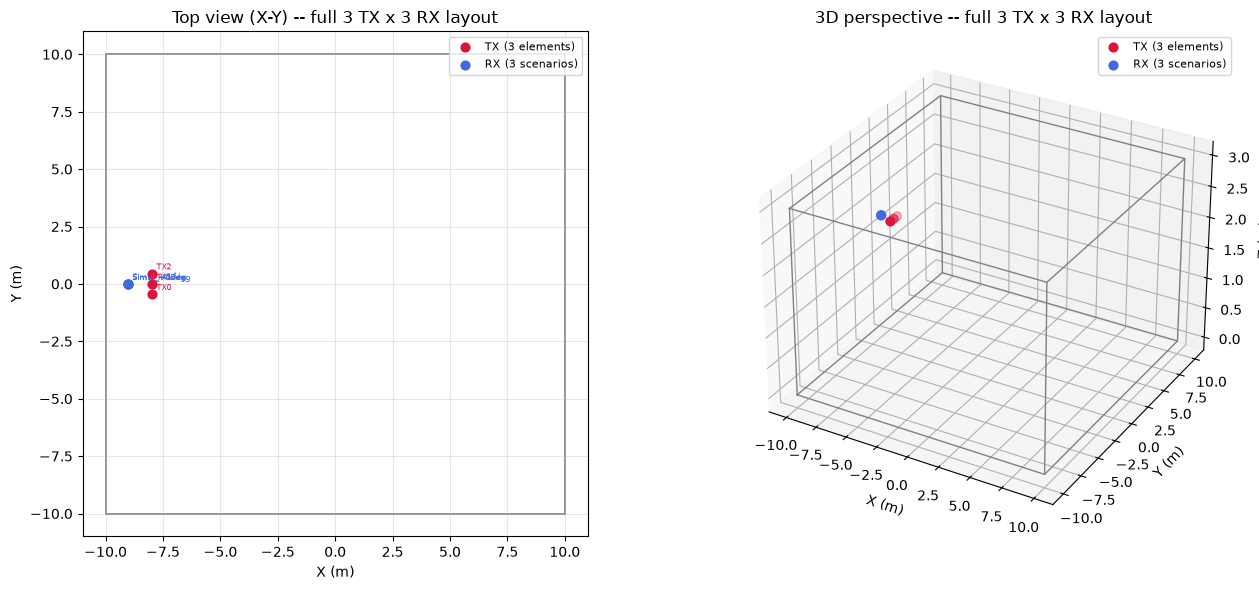

TX cluster: 3 elements, X=[-7.96, -7.96] m, Y=[-0.45, 0.45] m, Z=2.00 m
RX cluster: 3 scenarios, X=[-9.02, -9.01] m, Y=[-0.01, 0.01] m, Z=2.00 m


In [7]:
def plot_full_layout(tx_positions, sim_configs, room_x, room_y, room_z, figsize=(14, 6)):
    """Static overview of the full 3 TX x 3 RX layout: top view (X-Y) and 3D perspective.
    Positions only (no orientation/beam direction) -- a quick sanity-check of the geometry in
    TX_POSITIONS / SIMULATION_CONFIGS before running the main PathSolver loop."""
    tx_xyz = np.array(tx_positions, dtype=float)
    rx_xyz = np.array([cfg["rx_position"] for cfg in sim_configs], dtype=float)
    rx_labels = [cfg["name"] for cfg in sim_configs]
    hx, hy = room_x / 2, room_y / 2

    fig = plt.figure(figsize=figsize)

    # --- Top view (X-Y plane) ---
    ax0 = fig.add_subplot(1, 2, 1)
    ax0.add_patch(plt.Rectangle((-hx, -hy), room_x, room_y, fill=False, edgecolor="gray", lw=1.2))
    ax0.scatter(tx_xyz[:, 0], tx_xyz[:, 1], c="crimson", s=40, label="TX (3 elements)", zorder=3)
    ax0.scatter(rx_xyz[:, 0], rx_xyz[:, 1], c="royalblue", s=40, label="RX (3 scenarios)", zorder=3)
    for k, (x, y, _z) in enumerate(tx_xyz):
        ax0.annotate(f"TX{k}", (x, y), fontsize=6, color="crimson",
                     xytext=(3, 3), textcoords="offset points")
    for (x, y, _z), lbl in zip(rx_xyz, rx_labels):
        ax0.annotate(lbl, (x, y), fontsize=6, color="royalblue",
                     xytext=(3, 3), textcoords="offset points")
    ax0.set_xlabel("X (m)"); ax0.set_ylabel("Y (m)")
    ax0.set_title("Top view (X-Y) -- full 3 TX x 3 RX layout")
    ax0.set_aspect("equal")
    ax0.legend(fontsize=8)
    ax0.grid(alpha=0.3)

    # --- 3D perspective ---
    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    corners_xy = [(-hx, -hy), (hx, -hy), (hx, hy), (-hx, hy), (-hx, -hy)]
    for z in (0.0, room_z):
        xs, ys = zip(*corners_xy)
        ax1.plot(xs, ys, [z] * len(xs), color="gray", lw=1.0)
    for x, y in corners_xy[:-1]:
        ax1.plot([x, x], [y, y], [0.0, room_z], color="gray", lw=1.0)
    ax1.scatter(tx_xyz[:, 0], tx_xyz[:, 1], tx_xyz[:, 2], c="crimson", s=40, label="TX (3 elements)")
    ax1.scatter(rx_xyz[:, 0], rx_xyz[:, 1], rx_xyz[:, 2], c="royalblue", s=40, label="RX (3 scenarios)")
    ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")
    ax1.set_title("3D perspective -- full 3 TX x 3 RX layout")
    ax1.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"TX cluster: {len(tx_positions)} elements, "
          f"X=[{tx_xyz[:,0].min():.2f}, {tx_xyz[:,0].max():.2f}] m, "
          f"Y=[{tx_xyz[:,1].min():.2f}, {tx_xyz[:,1].max():.2f}] m, Z={tx_xyz[0,2]:.2f} m")
    print(f"RX cluster: {len(sim_configs)} scenarios, "
          f"X=[{rx_xyz[:,0].min():.2f}, {rx_xyz[:,0].max():.2f}] m, "
          f"Y=[{rx_xyz[:,1].min():.2f}, {rx_xyz[:,1].max():.2f}] m, Z={rx_xyz[0,2]:.2f} m")


plot_full_layout(TX_POSITIONS, SIMULATION_CONFIGS, ROOM_X, ROOM_Y, ROOM_Z)


### 5c. RX cluster — zoomed view

The 3 RX positions in `SIMULATION_CONFIGS` are only a few cm apart (they share the same receiver
location, just probed at 3 different lens angles), so at the full 20m room scale in section 5b
they all collapse into a single dot. This zooms in on just the RX cluster (top view + 3D
perspective), auto-scaled to its actual coordinate span, colored/labeled per scenario + lens
angle, so the 3 positions can be told apart.


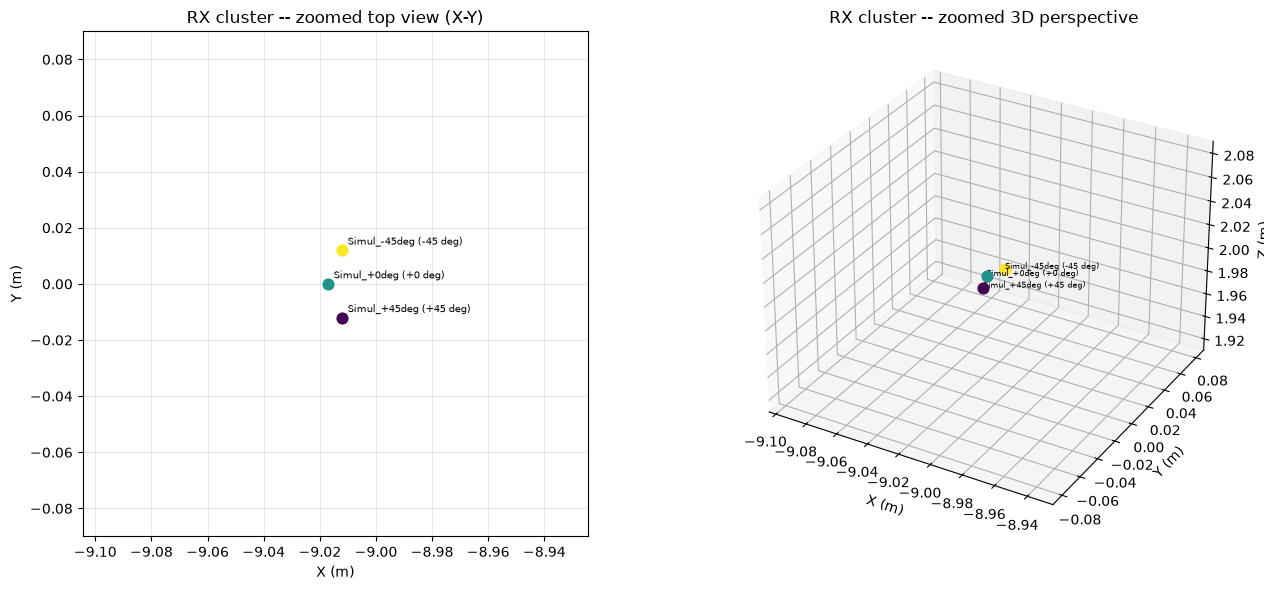

RX cluster span: X=[-9.01700, -9.01202] m (delta=0.00498 m), Y=[-0.01202, 0.01202] m (delta=0.02404 m), Z=[2.00000, 2.00000] m (delta=0.00000 m)


In [8]:
def plot_rx_zoom(sim_configs, pad_ratio=0.3, figsize=(14, 6)):
    """Zoomed-in view of just the RX cluster (top view + 3D), auto-scaled to the cluster's own
    coordinate span -- useful since the 3 RX scenario positions can be much closer together than
    the room dimensions (see plot_full_layout in 5b)."""
    rx_xyz = np.array([cfg["rx_position"] for cfg in sim_configs], dtype=float)
    labels = [f"{cfg['name']} ({cfg['rx_lens_angle_deg']:+d} deg)" for cfg in sim_configs]

    def pad(lo, hi, min_span=0.05):
        span = max(hi - lo, min_span)
        m = span * pad_ratio + min_span
        c = (lo + hi) / 2
        return c - span / 2 - m, c + span / 2 + m

    x_lo, x_hi = rx_xyz[:, 0].min(), rx_xyz[:, 0].max()
    y_lo, y_hi = rx_xyz[:, 1].min(), rx_xyz[:, 1].max()
    z_lo, z_hi = rx_xyz[:, 2].min(), rx_xyz[:, 2].max()
    x0, x1 = pad(x_lo, x_hi)
    y0, y1 = pad(y_lo, y_hi)
    z0, z1 = pad(z_lo, z_hi)

    colors = plt.cm.viridis(np.linspace(0, 1, len(sim_configs)))

    fig = plt.figure(figsize=figsize)

    ax0 = fig.add_subplot(1, 2, 1)
    for (x, y, _z), lbl, c in zip(rx_xyz, labels, colors):
        ax0.scatter(x, y, color=c, s=60, zorder=3)
        ax0.annotate(lbl, (x, y), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax0.set_xlim(x0, x1); ax0.set_ylim(y0, y1)
    ax0.set_xlabel("X (m)"); ax0.set_ylabel("Y (m)")
    ax0.set_title("RX cluster -- zoomed top view (X-Y)")
    ax0.set_aspect("equal")
    ax0.grid(alpha=0.3)

    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    for (x, y, z), lbl, c in zip(rx_xyz, labels, colors):
        ax1.scatter(x, y, z, color=c, s=60)
        ax1.text(x, y, z, lbl, fontsize=6)
    ax1.set_xlim(x0, x1); ax1.set_ylim(y0, y1); ax1.set_zlim(z0, z1)
    ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")
    ax1.set_title("RX cluster -- zoomed 3D perspective")

    plt.tight_layout()
    plt.show()

    print(f"RX cluster span: X=[{x_lo:.5f}, {x_hi:.5f}] m (delta={x_hi-x_lo:.5f} m), "
          f"Y=[{y_lo:.5f}, {y_hi:.5f}] m (delta={y_hi-y_lo:.5f} m), "
          f"Z=[{z_lo:.5f}, {z_hi:.5f}] m (delta={z_hi-z_lo:.5f} m)")


plot_rx_zoom(SIMULATION_CONFIGS)


## 6. Scene builder — 3 TX (same pattern, simultaneous radiation) + 1 RX (lens differs per simulation)


In [9]:
def build_scene(tx_positions, tx_orientation_deg, tx_pattern_name,
                 rx_position, rx_orientation_deg, rx_pattern_name,
                 xml_path=ROOM_XML, frequency=F_C):
    # Scene with ALL TX elements active at once (same pattern) + 1 Receiver.
    scene = load_scene(xml_path)
    scene.frequency = frequency
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern=tx_pattern_name, polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern=rx_pattern_name, polarization="V")

    tx_o = mi.Point3f(*[float(v) for v in np.deg2rad(tx_orientation_deg)])
    for k, pos in enumerate(tx_positions):
        tx_p = [float(v) for v in pos]
        scene.add(Transmitter(f"tx{k}", position=tx_p, orientation=tx_o, display_radius=0.15))

    rx_o = mi.Point3f(*[float(v) for v in np.deg2rad(rx_orientation_deg)])
    rx_p = [float(v) for v in rx_position]
    scene.add(Receiver("rx", position=rx_p, orientation=rx_o, display_radius=0.15))
    return scene


def compute_H(scene, f_c=F_C, bw=BW, n_f=N_F, max_depth=3, samples_per_src=1_000_000):
    # PathSolver -> paths.cfr() -> Hf(freq) for 3 TX (simultaneous) x 1 RX (Sionna 2).
    solver = PathSolver()
    paths = solver(
        scene, max_depth=max_depth, samples_per_src=samples_per_src,
        los=True, specular_reflection=True, diffuse_reflection=False,
        refraction=False, synthetic_array=True,
    )
    freqs = np.linspace(f_c - bw / 2, f_c + bw / 2, n_f)
    h_wb = paths.cfr(frequencies=mi.Float(freqs), normalize_delays=False, out_type="numpy")
    Hf = np.asarray(np.squeeze(h_wb))  # -> [n_tx, n_f] since n_rx=1
    if Hf.ndim == 1:
        Hf = Hf.reshape(1, -1)
    return Hf, freqs, paths


## 7. Beamform validation utilities (position, orientation, peak beam direction in world frame)

Adapted from `AntennaSetupOrientation_Lens45deg.ipynb`: `extract_scene()` finds the peak-gain
direction of each pattern (`tx_array`/`rx_array`) then projects it into the world frame using the
device's actual position+orientation in the scene; `plot_scene_pythreejs()` displays it as an
interactive 3D arrow + legend (position, peak gain, direction). This differs from the "antenna
pattern profile" in section 7b (which is just the local pattern shape) -- here what's validated is
**whether the TX/RX beam actually points where intended in the real scene**. These functions are
called on **every iteration of the simulation loop** (section 8), not just once at the start.


In [10]:
def _p3(v):
    def scalar(c):
        try:
            return float(c[0])
        except TypeError:
            return float(c)
    return np.array([scalar(v.x), scalar(v.y), scalar(v.z)])

def _apply_R(R, v):
    return np.array([R[0,0]*v[0]+R[0,1]*v[1]+R[0,2]*v[2],
                      R[1,0]*v[0]+R[1,1]*v[1]+R[1,2]*v[2],
                      R[2,0]*v[0]+R[2,1]*v[1]+R[2,2]*v[2]])

def pattern_peak_local(pattern_obj, n_theta=91, n_phi=181):
    theta = np.linspace(0., np.pi, n_theta, dtype=np.float32)
    phi = np.linspace(-np.pi, np.pi, n_phi, dtype=np.float32)
    T, P = np.meshgrid(theta, phi, indexing="ij")
    Tf, Pf = mi.Float(T.ravel()), mi.Float(P.ravel())
    g_tot = np.zeros(T.size)
    for port in pattern_obj.patterns:
        c_t, c_p = port(Tf, Pf)
        g_tot = g_tot + np.array(c_t.real)**2 + np.array(c_t.imag)**2 \
                       + np.array(c_p.real)**2 + np.array(c_p.imag)**2
    i = int(np.argmax(g_tot))
    t_pk, p_pk = float(T.ravel()[i]), float(P.ravel()[i])
    v_local = np.array([np.sin(t_pk)*np.cos(p_pk), np.sin(t_pk)*np.sin(p_pk), np.cos(t_pk)])
    g_db = 10.*np.log10(g_tot[i] + 1e-15)
    return v_local, g_db, np.rad2deg(t_pk), np.rad2deg(p_pk)

def extract_scene(scene):
    devices = []
    for kind, coll, array in (("tx", scene.transmitters, scene.tx_array),
                               ("rx", scene.receivers, scene.rx_array)):
        if len(coll) == 0:
            continue
        v_local, g_db, t_pk, p_pk = pattern_peak_local(array.antenna_pattern)
        for name, dev in coll.items():
            pos = _p3(dev.position)
            orient = _p3(dev.orientation)
            v_world = _apply_R(R_of(list(orient)), v_local)
            devices.append(dict(name=name, kind=kind, position=pos,
                                 orientation_deg=np.rad2deg(orient),
                                 peak_gain_db=g_db, theta_peak_deg=t_pk, phi_peak_deg=p_pk,
                                 beam_dir_world=v_world))
    return devices

def plot_scene_pythreejs(scene, devices, beam_length=2.0, resolution=(700, 500)):
    import pythreejs as p3s
    from ipywidgets import widgets
    from IPython.display import display

    camera = p3s.PerspectiveCamera(position=[8, 8, 6], up=[0, 0, 1],
                                    aspect=resolution[0] / resolution[1])
    ambient = p3s.AmbientLight(intensity=0.9)
    orbit = p3s.OrbitControls(controlling=camera)
    p3_scene = p3s.Scene(background="#202020", children=[camera, ambient])

    try:
        bb = scene.mi_scene.bbox()
        lo, hi = _p3(bb.min), _p3(bb.max)
        corners = [[x, y, z] for x in (lo[0], hi[0]) for y in (lo[1], hi[1]) for z in (lo[2], hi[2])]
        edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
        seg = []
        for a, b in edges:
            seg += [corners[a], corners[b]]
        room_geo = p3s.BufferGeometry(
            attributes={"position": p3s.BufferAttribute(np.array(seg, dtype=np.float32))})
        p3_scene.add(p3s.LineSegments(room_geo, p3s.LineBasicMaterial(color="#888888")))
    except Exception:
        pass

    colors = {"tx": "#dc143c", "rx": "#4169e1"}
    legend_rows = []
    for d in devices:
        color = colors[d["kind"]]
        pos = [float(x) for x in d["position"]]
        u = [float(x) for x in d["beam_dir_world"]]
        marker = p3s.Mesh(p3s.SphereGeometry(radius=0.12, widthSegments=16, heightSegments=16),
                           p3s.MeshBasicMaterial(color=color), position=pos)
        p3_scene.add(marker)
        arrow = p3s.ArrowHelper(dir=u, origin=pos, length=beam_length, color=color,
                                 headLength=0.35 * beam_length, headWidth=0.15 * beam_length)
        p3_scene.add(arrow)
        legend_rows.append(widgets.HTML(
            f"<b style='color:{color}'>{d['name']}</b> [{d['kind']}]<br>"
            f"pos=({pos[0]:.2f}, {pos[1]:.2f}, {pos[2]:.2f}) m<br>"
            f"peak gain={d['peak_gain_db']:.1f} dB, "
            f"theta={d['theta_peak_deg']:.0f} deg, phi={d['phi_peak_deg']:.0f} deg<br>"
            f"orientation=({d['orientation_deg'][0]:.0f} deg, {d['orientation_deg'][1]:.0f} deg, "
            f"{d['orientation_deg'][2]:.0f} deg)<hr style='margin:4px 0'>"))
    renderer = p3s.Renderer(scene=p3_scene, camera=camera, controls=[orbit],
                             width=resolution[0], height=resolution[1], antialias=True)
    legend = widgets.VBox(legend_rows,
                           layout=widgets.Layout(padding="0 0 0 10px", overflow_y="auto",
                                                  max_height=f"{resolution[1]}px"))
    ui = widgets.HBox([renderer, legend])
    display(ui)
    return ui


### 7b. Antenna pattern profile (radiation pattern, `compute_gain`/`show`)

Adapted from `AntennaSetupOrientation_Lens45deg.ipynb`: for each farfield used in the simulation
loop, show `pat.compute_gain()` (check efficiency, should be <= ~100% for real HFSS data) +
`pat.show()` (3D radiation pattern) + local boresight direction (peak gain).

- **TX** uses the same pattern for all 3 elements (fixed across simulations) -- the TX profile is
  shown only **once**, and only if `TX_PATTERN_MODE = "csv"` (if `"iso"`/omni, there's no custom
  farfield to review).
- **RX** uses a different lens farfield per simulation -- the RX profile is shown **once per
  unique lens angle** (cached; with 3 scenarios x 3 different angles, this is automatically 3
  times).

**On `pat.show()`**: `SHOW_ANTENNA_PROFILE_PLOTS` (configuration cell, section 5) is still provided
in case you want to skip the 3D pattern plot (e.g. to speed up the loop, or if the
`pythreejs`/matplotlib rendering doesn't suit how you run the notebook) -- gain, efficiency, and
boresight info are still printed regardless of this toggle's value.


In [11]:
def get_builtin_pattern(name, polarization="V", polarization_model="tr38901_2"):
    """Get a built-in Sionna pattern instance (not HFSS) -- "iso", "dipole", "hw_dipole", or
    "tr38901" -- via the same registry used by PlanarArray(pattern=name). Returns a plain
    AntennaPattern object (compute_gain/show/patterns all present), usable together with
    show_antenna_profile() exactly like HFSSPattern."""
    factory = rt.antenna_pattern.antenna_pattern_registry.get(name)
    return factory(polarization=polarization, polarization_model=polarization_model)


def show_antenna_profile(pat, label=""):
    """Show the radiation pattern profile of a single antenna element (any HFSSPattern/
    AntennaPattern): compute_gain() (efficiency, should be <= ~100% for real HFSS data), show()
    (3D pattern plot), and local boresight direction (peak gain) -- exactly as in
    AntennaSetupOrientation_Lens45deg.ipynb.

    NB: pat.show() is controlled by SHOW_ANTENNA_PROFILE_PLOTS (see the configuration cell)."""
    print(f"--- Antenna profile: {label} ---")
    pat.compute_gain()
    if SHOW_ANTENNA_PROFILE_PLOTS:
        pat.show()
    v_local, g_db, t_pk, p_pk = pattern_peak_local(pat)
    print(f"[{label}] Local boresight: {np.round(v_local, 3)} | "
          f"peak {g_db:.2f} dB at theta={t_pk:.0f} deg, phi={p_pk:.0f} deg")
    return v_local, g_db, t_pk, p_pk


### 7c. TX Antenna Profile — review before the main loop

TX uses the **same** pattern for all 3 elements & all simulations (fixed, not a lens), so there's
only 1 TX profile to review (unlike RX, which differs per scenario). If
`TX_PATTERN_MODE = "csv"`, this cell shows `compute_gain()` + boresight direction for
`TX_CUSTOM_CSV`. If `TX_PATTERN_MODE = "iso"` (or another Sionna built-in pattern --
`"dipole"`/`"hw_dipole"`/`"tr38901"`), the profile is **still shown** -- taken directly from
Sionna's built-in pattern registry (`get_builtin_pattern`), not just an HFSS CSV. All of this runs
**before** the main loop (section 8).

The flag (`_shown_tx_profile`) in this cell is shared with the main loop -- if it was already shown
here, it won't be shown again inside the loop.


TX ANTENNA PROFILE -- review before the main loop
--- Antenna profile: TX (3 elements, Sionna built-in pattern: iso) ---
Directivity [dB]: -6.37e-05
Gain [dB]: 0.0
Efficiency [%]: 1e+02
[TX (3 elements, Sionna built-in pattern: iso)] Local boresight: [-0.  0.  1.] | peak 0.00 dB at theta=0 deg, phi=-180 deg


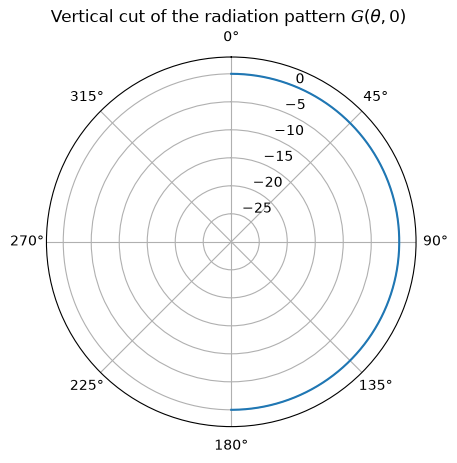

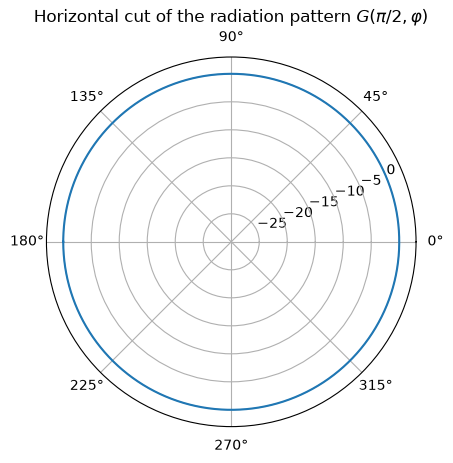

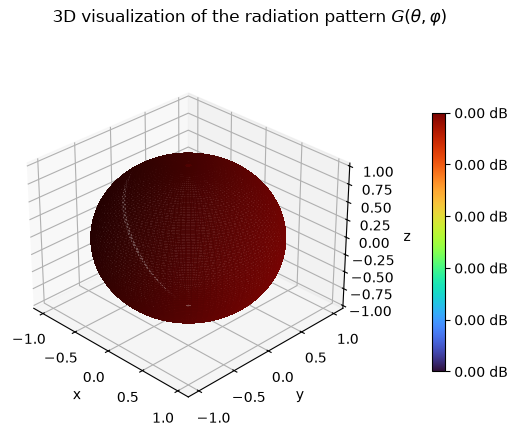

In [12]:
print("=" * 60)
print("TX ANTENNA PROFILE -- review before the main loop")
print("=" * 60)

# Flag for the TX profile already shown -- shared with the main loop (section 8) so it isn't
# shown twice there.
_shown_tx_profile = False

if TX_PATTERN_MODE == "csv":
    tx_pat = HFSSPattern(TX_CUSTOM_CSV, freq_ghz=TX_CUSTOM_CSV_FREQ_GHZ,
                          param_filters=TX_CUSTOM_CSV_PARAM_FILTERS, rot_deg=TX_CUSTOM_CSV_ROT_DEG)
    show_antenna_profile(tx_pat, label=f"TX (3 elements, custom pattern, {TX_CUSTOM_CSV})")
else:
    # Not HFSS -- still show the built-in Sionna pattern profile (e.g. "iso") via its registry.
    tx_pat = get_builtin_pattern(TX_PATTERN_MODE)
    show_antenna_profile(tx_pat, label=f"TX (3 elements, Sionna built-in pattern: {TX_PATTERN_MODE})")

_shown_tx_profile = True


### 7d. RX Antenna Profile — review all scenarios before the main loop

Reviews `compute_gain()` + boresight direction for **all** RX farfields used in
`SIMULATION_CONFIGS` (3 scenarios), once per unique CSV, **before** the main loop (section 8) runs
-- so you can check the efficiency & peak-gain direction of each RX lens angle right away without
waiting for all 3 `PathSolver` runs to finish first.

The cache (`_shown_rx_profiles`) in this cell is shared with the main loop -- if it was already
shown here, it won't be shown again inside the loop.


RX ANTENNA PROFILE -- review all scenarios before the main loop
--- Antenna profile: RX Simul_+45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv) ---
Directivity [dB]: 14.7
Gain [dB]: 14.3
Efficiency [%]: 91.7
[RX Simul_+45deg (farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv)] Local boresight: [ 0.058  0.827 -0.559] | peak 14.29 dB at theta=124 deg, phi=86 deg
--- Antenna profile: RX Simul_+0deg (farfieldAntennaData/FarFieldData_0deg_detailFreq.csv) ---
Directivity [dB]: 16.8
Gain [dB]: 16.5
Efficiency [%]: 92.5
[RX Simul_+0deg (farfieldAntennaData/FarFieldData_0deg_detailFreq.csv)] Local boresight: [ 0.035  0.999 -0.   ] | peak 16.51 dB at theta=90 deg, phi=88 deg

2 unique RX farfields reviewed out of 3 scenarios.


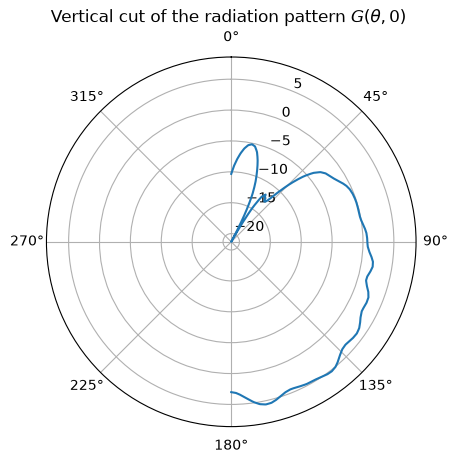

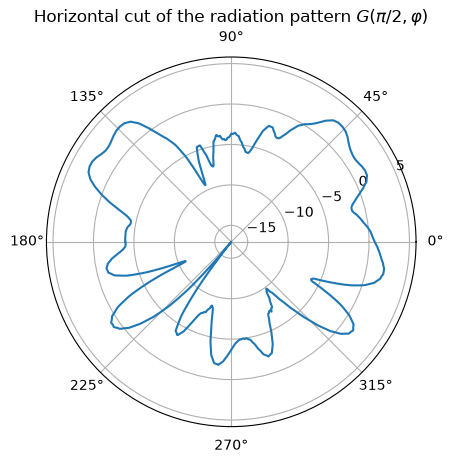

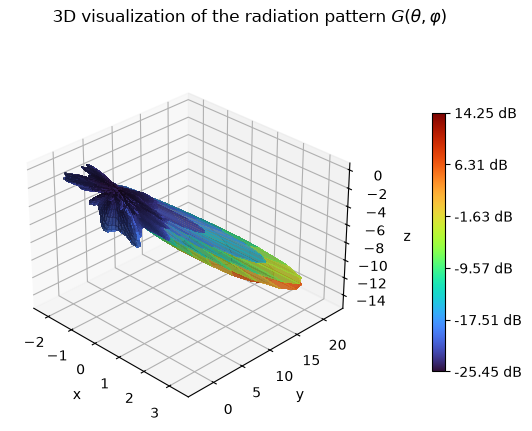

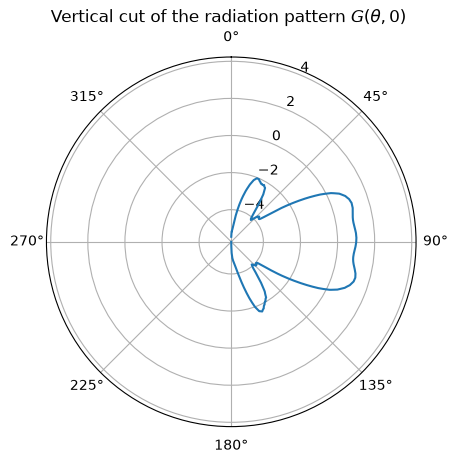

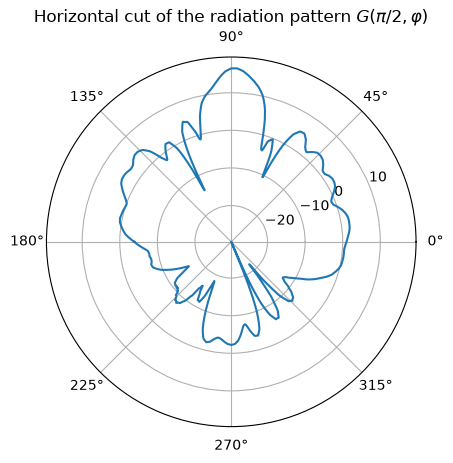

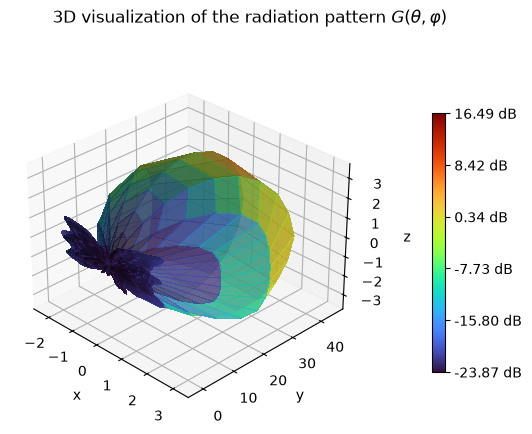

In [13]:
print("=" * 60)
print("RX ANTENNA PROFILE -- review all scenarios before the main loop")
print("=" * 60)

# Cache of RX antenna profiles already shown (per unique CSV) -- shared with the main loop
# (section 8) so they aren't shown twice there.
_shown_rx_profiles = set()

for cfg in SIMULATION_CONFIGS:
    csv_path = cfg["rx_farfield_csv"]
    if csv_path in _shown_rx_profiles:
        continue
    rx_pat = HFSSPattern(csv_path, freq_ghz=FREQ_GHZ, param_filters=cfg["rx_farfield_param_filters"],
                          rot_deg=HFSS_ROT_DEG)
    show_antenna_profile(rx_pat, label=f"RX {cfg['name']} ({csv_path})")
    _shown_rx_profiles.add(csv_path)

print(f"\n{len(_shown_rx_profiles)} unique RX farfields reviewed out of {len(SIMULATION_CONFIGS)} scenarios.")


## 8. Main loop — 3 simulations (3 RX scenarios, each with 3 simultaneous TX)

Each simulation = 1 scene: 3 TX (same pattern, simultaneous radiation) + 1 RX
(position/orientation/lens from `SIMULATION_CONFIGS[i]`). The RX pattern (`hfss_rx`) is
re-registered each simulation to its respective lens angle. Every iteration also runs
**beamform validation** (`extract_scene` + `plot_scene_pythreejs`): each device's position, peak
gain, and peak beam direction (world frame) are printed + drawn as an interactive 3D arrow -- so
you can immediately see whether the TX/RX beams actually point at each other correctly for that
scenario, not just the pattern shape. After `PathSolver` finishes, each iteration also shows a
**scene + ray path preview** from that solver run itself (`scene.preview(paths=paths, ...)` --
LOS/specular reflection/diffuse/diffraction, per Sionna's built-in legend), then plots the
**power received at RX from TX** (`plot_received_power`): power per TX element (3 curves) + total
combined power, vs frequency. The result is `H_all[rx_config, tx_element, freq]` -- 3 x 3 x `N_F`,
from 3 `PathSolver` runs (not 9, since TX no longer needs to be simulated one at a time).


In [14]:
def plot_received_power(cfg, Hf, freqs):
    """Print & (if SHOW_POWER_PLOTS) plot the power received at RX from TX (per element & total)
    vs frequency, for 1 simulation. Total power = incoherent sum |H_i(f)|^2 over TX elements
    (assumes each element transmits equal power, with no phase weighting/beamforming -- if a
    per-element weight w_i is added later, change to |sum_i w_i H_i(f)|^2 for coherent combined
    power).

    The plot is controlled by SHOW_POWER_PLOTS (see the configuration cell); the summary numbers
    (peak/mean per element) are still printed regardless of its value."""
    power_per_tx_db = 20 * np.log10(np.abs(Hf) + 1e-15)                      # [n_tx, n_f]
    power_total_db = 10 * np.log10(np.sum(np.abs(Hf) ** 2, axis=0) + 1e-15)  # [n_f]

    print(f"    RX received power ({cfg['name']}): peak per element (dB) = "
          f"{np.round(power_per_tx_db.max(axis=1), 1)}")
    print(f"    Total combined power (dB): peak={power_total_db.max():.1f}  "
          f"mean={power_total_db.mean():.1f}")

    if not SHOW_POWER_PLOTS:
        return

    f_ghz = freqs / 1e9
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for k in range(Hf.shape[0]):
        ax[0].plot(f_ghz, power_per_tx_db[k], lw=0.9, label=f"TX{k}")
    ax[0].set_xlabel("Frequency (GHz)")
    ax[0].set_ylabel("Received power (dB)")
    ax[0].set_title(f"Power per TX element -> RX  ({cfg['name']})")
    ax[0].legend(fontsize=7, ncol=3)
    ax[0].grid(alpha=0.3)

    ax[1].plot(f_ghz, power_total_db, color="crimson", lw=1.5)
    ax[1].set_xlabel("Frequency (GHz)")
    ax[1].set_ylabel("Total received power (dB)")
    ax[1].set_title(f"Total power (3 TX -> 1 RX)  ({cfg['name']})")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


Saved room_20x20.xml (20m x 20m x 3m)

[1/3] Simul_+45deg  csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv  rx_pos=[-9.01 -0.01  2.  ]
  --- Beamform validation: Simul_+45deg ---
   tx0 [tx] pos=[-7.961 -0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx1 [tx] pos=[-7.961  0.     2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx2 [tx] pos=[-7.961  0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
    rx [rx] pos=[-9.012 -0.012  2.   ]  peak_gain=14.3 dB @ theta=124 deg, phi=86 deg  world_beam_dir=[ 0.827  0.559 -0.058]


    |H| peak per TX element (dB): [-76.5 -76.5 -76.9]
  --- Ray preview: Simul_+45deg ---


C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\drjit\__init__.py:1353: RuntimeWarning: invalid value encountered in multiply
  return arg * rsqrt(squared_norm(arg))
C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


    RX received power (Simul_+45deg): peak per element (dB) = [-76.5 -76.5 -76.9]
    Total combined power (dB): peak=-72.7  mean=-76.8


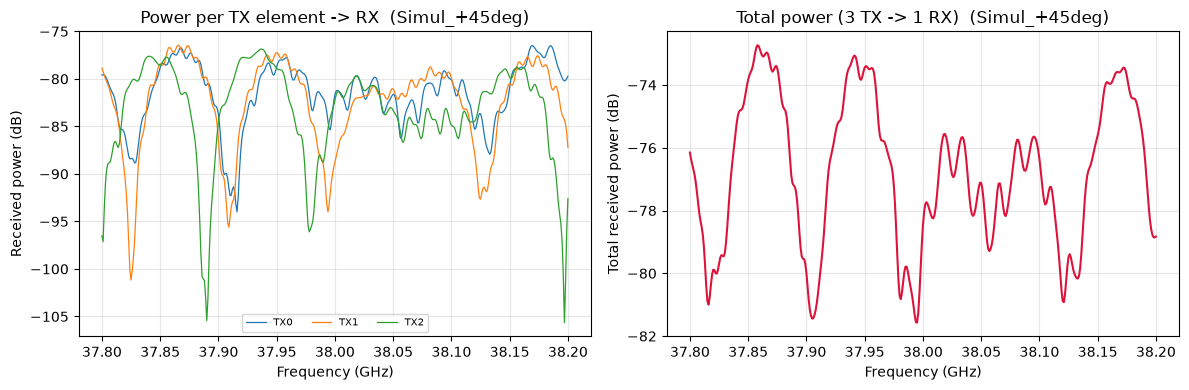


[2/3] Simul_+0deg  csv=farfieldAntennaData/FarFieldData_0deg_detailFreq.csv  rx_pos=[-9.02  0.    2.  ]
  --- Beamform validation: Simul_+0deg ---
   tx0 [tx] pos=[-7.961 -0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx1 [tx] pos=[-7.961  0.     2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx2 [tx] pos=[-7.961  0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
    rx [rx] pos=[-9.017  0.     2.   ]  peak_gain=16.5 dB @ theta=90 deg, phi=88 deg  world_beam_dir=[ 0.999 -0.     0.035]


    |H| peak per TX element (dB): [-74.2 -93.4 -75.3]
  --- Ray preview: Simul_+0deg ---


C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\drjit\__init__.py:1353: RuntimeWarning: invalid value encountered in multiply
  return arg * rsqrt(squared_norm(arg))
C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


    RX received power (Simul_+0deg): peak per element (dB) = [-74.2 -93.4 -75.3]
    Total combined power (dB): peak=-71.7  mean=-73.1


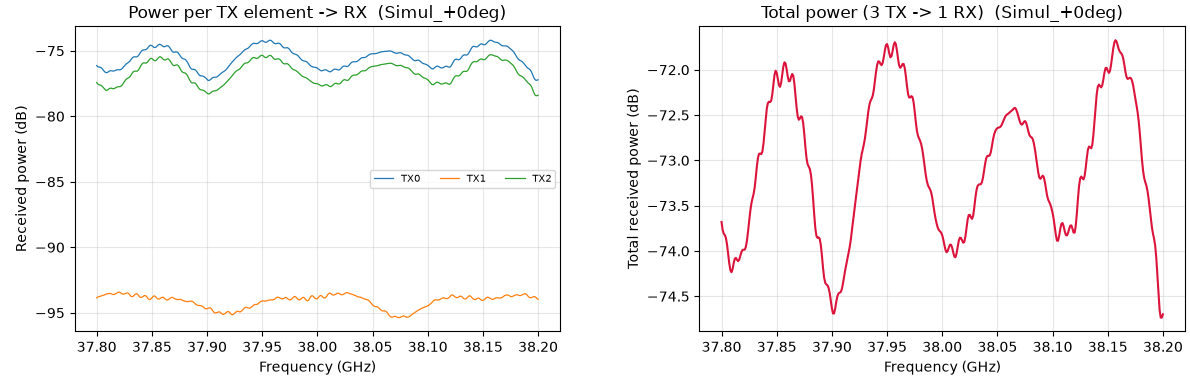


[3/3] Simul_-45deg  csv=farfieldAntennaData/FarFieldData_m45deg_detailFreq.csv  rx_pos=[-9.01  0.01  2.  ]
  --- Beamform validation: Simul_-45deg ---
   tx0 [tx] pos=[-7.961 -0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx1 [tx] pos=[-7.961  0.     2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
   tx2 [tx] pos=[-7.961  0.45   2.   ]  peak_gain=0.0 dB @ theta=0 deg, phi=-180 deg  world_beam_dir=[-0.  1. -0.]
    rx [rx] pos=[-9.012  0.012  2.   ]  peak_gain=14.2 dB @ theta=56 deg, phi=86 deg  world_beam_dir=[ 0.827 -0.559 -0.058]


    |H| peak per TX element (dB): [-76.4 -77.5 -75.9]
  --- Ray preview: Simul_-45deg ---


C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\drjit\__init__.py:1353: RuntimeWarning: invalid value encountered in multiply
  return arg * rsqrt(squared_norm(arg))
C:\Users\DELL 7540\.conda\envs\sionna_env\Lib\site-packages\jupyter_client\session.py:727: UserWarning: Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant
  content = self.pack(content)


    RX received power (Simul_-45deg): peak per element (dB) = [-76.4 -77.5 -75.9]
    Total combined power (dB): peak=-73.0  mean=-76.5


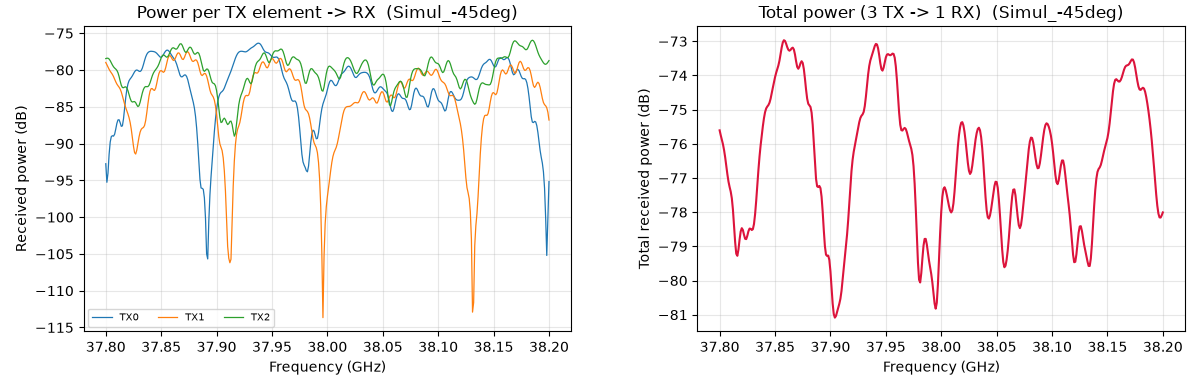


H_all shape: (3, 3, 401)  # (rx_config, tx_element, freq)


In [15]:
generate_room_xml(ROOM_X, ROOM_Y, ROOM_Z, ROOM_XML)

n_rx_cfg = len(SIMULATION_CONFIGS)
n_tx_el = len(TX_POSITIONS)

H_all = np.zeros((n_rx_cfg, n_tx_el, N_F), dtype=complex)
freqs_ref = None

# Cache of RX antenna profiles already shown (per unique CSV) -- shared with the "RX Antenna
# Profile" cell (section 7d); if that cell already ran, they won't be shown twice here.
try:
    _shown_rx_profiles
except NameError:
    _shown_rx_profiles = set()

# TX profile flag -- shared with the "TX Antenna Profile" cell (section 7c); if that cell already
# ran, it won't be shown twice here.
try:
    _shown_tx_profile
except NameError:
    _shown_tx_profile = False

# TX: SAME pattern for all elements & all simulations -- register & show the profile only once
if TX_PATTERN_MODE == "csv":
    register_antenna_pattern("hfss_tx", make_hfss_factory(
        TX_CUSTOM_CSV, freq_ghz=TX_CUSTOM_CSV_FREQ_GHZ,
        param_filters=TX_CUSTOM_CSV_PARAM_FILTERS, rot_deg=TX_CUSTOM_CSV_ROT_DEG))
    tx_pattern_name = "hfss_tx"
    if not _shown_tx_profile:
        tx_pat = HFSSPattern(TX_CUSTOM_CSV, freq_ghz=TX_CUSTOM_CSV_FREQ_GHZ,
                              param_filters=TX_CUSTOM_CSV_PARAM_FILTERS, rot_deg=TX_CUSTOM_CSV_ROT_DEG)
        show_antenna_profile(tx_pat, label="TX (3 elements, custom pattern)")
        _shown_tx_profile = True
else:
    tx_pattern_name = "iso"
    if not _shown_tx_profile:
        tx_pat = get_builtin_pattern(TX_PATTERN_MODE)
        show_antenna_profile(tx_pat, label=f"TX (3 elements, Sionna built-in pattern: {TX_PATTERN_MODE})")
        _shown_tx_profile = True

for i, cfg in enumerate(SIMULATION_CONFIGS):
    print(f"\n[{i+1}/{n_rx_cfg}] {cfg['name']}  csv={cfg['rx_farfield_csv']}  "
          f"rx_pos={np.round(cfg['rx_position'], 2)}")

    csv_path, param_filters = cfg["rx_farfield_csv"], cfg["rx_farfield_param_filters"]
    register_antenna_pattern("hfss_rx", make_hfss_factory(
        csv_path, freq_ghz=FREQ_GHZ, param_filters=param_filters, rot_deg=HFSS_ROT_DEG))
    if csv_path not in _shown_rx_profiles:
        rx_pat = HFSSPattern(csv_path, freq_ghz=FREQ_GHZ, param_filters=param_filters,
                              rot_deg=HFSS_ROT_DEG)
        show_antenna_profile(rx_pat, label=f"RX {cfg['name']} ({csv_path})")
        _shown_rx_profiles.add(csv_path)

    scene = build_scene(
        tx_positions=TX_POSITIONS, tx_orientation_deg=TX_ORIENTATION_DEG, tx_pattern_name=tx_pattern_name,
        rx_position=cfg["rx_position"], rx_orientation_deg=cfg["rx_orientation_deg"],
        rx_pattern_name="hfss_rx",
    )

    # --- Per-simulation sanity-check: validate the beamform direction & magnitude in the real scene ---
    # (not just the local pattern shape like show_antenna_profile -- here the position/orientation/
    # beam are already projected into the world frame, so you can see whether the TX/RX beams
    # really point at each other)
    print(f"  --- Beamform validation: {cfg['name']} ---")
    _devices = extract_scene(scene)
    for d in _devices:
        print(f"  {d['name']:>4s} [{d['kind']}] pos={np.round(d['position'], 3)}  "
              f"peak_gain={d['peak_gain_db']:.1f} dB @ theta={d['theta_peak_deg']:.0f} deg, "
              f"phi={d['phi_peak_deg']:.0f} deg  world_beam_dir={np.round(d['beam_dir_world'], 3)}")
    plot_scene_pythreejs(scene, _devices, beam_length=2.0)

    Hf, freqs_ref, paths = compute_H(scene, f_c=F_C, bw=BW, n_f=N_F)
    H_all[i] = Hf

    gains_db = 20 * np.log10(np.abs(H_all[i]).max(axis=1) + 1e-15)
    print("    |H| peak per TX element (dB):", np.round(gains_db, 1))

    # --- Scene preview + ray path from the PathSolver result (LOS/reflection/diffraction), per simulation ---
    if SHOW_RAY_PREVIEW:
        print(f"  --- Ray preview: {cfg['name']} ---")
        scene.preview(paths=paths, clip_at=ROOM_Z - 0.1, show_devices=True, show_orientations=True)

    # --- Visualize the power received at RX from TX (per element & total) vs frequency ---
    plot_received_power(cfg, Hf, freqs_ref)

print("\nH_all shape:", H_all.shape, " # (rx_config, tx_element, freq)")


## 9. Per-RX-scenario evaluation

Each `H_all[i]` (shape `[3 TX elements, n_freq]`) is treated like one row of a MIMO channel
(reference: `Setup_20mx20m_9x9.ipynb`). Here the correlation between the **3 TX elements** is real
and simultaneous (3 TX radiating at once in 1 scene) as seen from 1 RX with lens angle
`SIMULATION_CONFIGS[i]["rx_lens_angle_deg"]`, along with the transmit-beamforming capacity (full
CSIT, MRT) to that single receiver. Note: what is **not** simultaneous is across-**scenarios** (the
3 RX position/orientation/lens combinations are tested one at a time, not 3 active RX at once).


In [16]:
def tx_branch_correlation(Hf_i):
    # Correlation between TX elements (rows), with realizations = frequency samples. Returns a 3x3 matrix.
    n_tx, n_f = Hf_i.shape
    X = Hf_i  # [n_tx, n_f]
    R = (X @ X.conj().T) / n_f
    d = np.sqrt(np.real(np.diag(R)))
    return R / np.outer(d, d)

def mrt_capacity(Hf_i, snr_db_range=np.arange(-10, 31, 2)):
    # Transmit-beamforming capacity (MRT, full CSIT) to 1 RX: C = log2(1 + (SNR/n_tx) * ||h||^2).
    n_tx, n_f = Hf_i.shape
    Hn = Hf_i / np.sqrt(np.mean(np.abs(Hf_i)**2))
    caps = np.zeros((len(snr_db_range), n_f))
    for si, snr_db in enumerate(snr_db_range):
        snr = 10**(snr_db / 10)
        caps[si] = np.log2(1 + (snr / n_tx) * np.sum(np.abs(Hn)**2, axis=0))
    return snr_db_range, caps.mean(axis=1)

summary_rows = []
corr_all = []
for i, cfg in enumerate(SIMULATION_CONFIGS):
    Hf_i = H_all[i]
    R_tx = tx_branch_correlation(Hf_i)
    corr_all.append(R_tx)
    offdiag = R_tx[~np.eye(n_tx_el, dtype=bool)]
    snr_range, C_erg = mrt_capacity(Hf_i)
    combined_gain_db = 10 * np.log10(np.mean(np.sum(np.abs(Hf_i)**2, axis=0)) + 1e-15)
    summary_rows.append({
        "name": cfg["name"],
        "rx_lens_angle_deg": cfg["rx_lens_angle_deg"],
        "combined_gain_db": combined_gain_db,
        "mean_|rho|_offdiag": np.mean(np.abs(offdiag)),
        "max_|rho|_offdiag": np.max(np.abs(offdiag)),
        "capacity_10dB_bits/s/Hz": C_erg[np.where(snr_range == 10)[0][0]],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("combined_gain_db", ascending=False)
summary_df


,name,rx_lens_angle_deg,combined_gain_db,mean_|rho|_offdiag,max_|rho|_offdiag,capacity_10dB_bits/s/Hz
1,Simul_+0deg,0,-72.977201,0.972858,0.999864,3.439221
2,Simul_-45deg,-45,-76.060374,0.766971,0.829936,3.330617
0,Simul_+45deg,45,-76.177716,0.806024,0.925461,3.296537


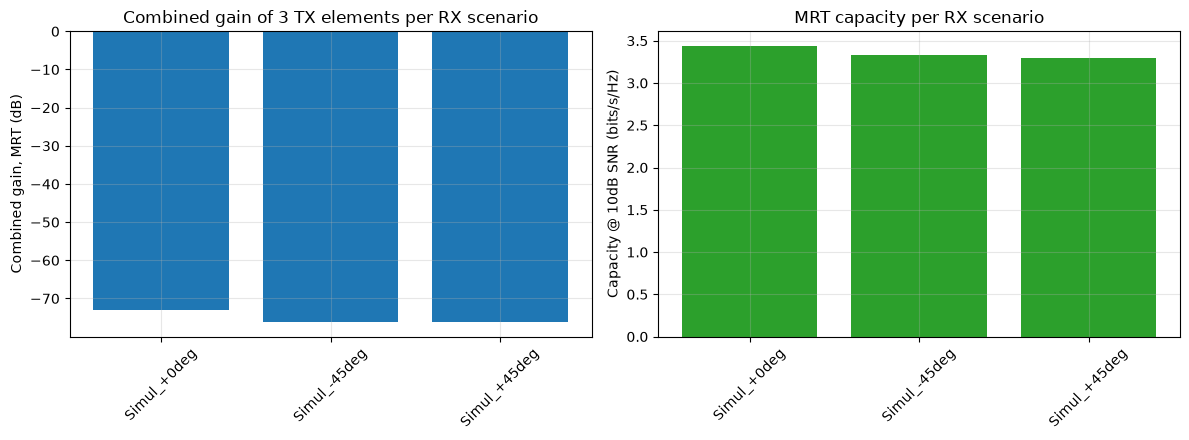

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(summary_df["name"], summary_df["combined_gain_db"], color="tab:blue")
ax[0].set_ylabel("Combined gain, MRT (dB)")
ax[0].set_title("Combined gain of 3 TX elements per RX scenario")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(alpha=0.3)

ax[1].bar(summary_df["name"], summary_df["capacity_10dB_bits/s/Hz"], color="tab:green")
ax[1].set_ylabel("Capacity @ 10dB SNR (bits/s/Hz)")
ax[1].set_title("MRT capacity per RX scenario")
ax[1].tick_params(axis="x", rotation=45)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


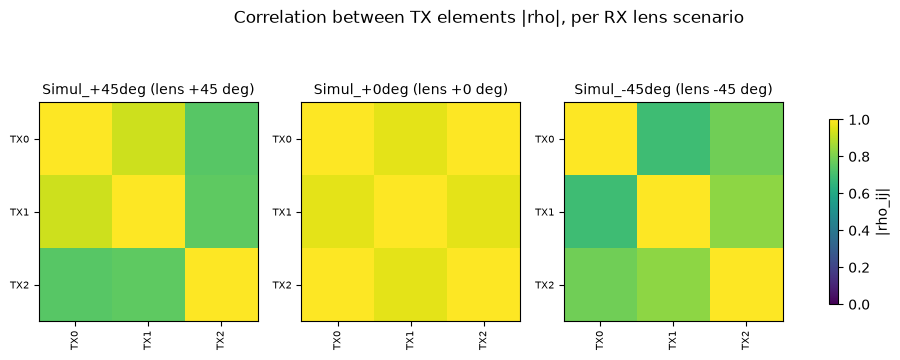

In [18]:
fig, axes = plt.subplots(1, n_rx_cfg, figsize=(4 * n_rx_cfg, 4))
tx_labels = [f"TX{k}" for k in range(n_tx_el)]
for i, cfg in enumerate(SIMULATION_CONFIGS):
    a = axes[i]
    im = a.imshow(np.abs(corr_all[i]), vmin=0, vmax=1, cmap="viridis")
    a.set_title(f"{cfg['name']} (lens {cfg['rx_lens_angle_deg']:+d} deg)", fontsize=10)
    a.set_xticks(range(n_tx_el)); a.set_xticklabels(tx_labels, rotation=90, fontsize=7)
    a.set_yticks(range(n_tx_el)); a.set_yticklabels(tx_labels, fontsize=7)
fig.suptitle("Correlation between TX elements |rho|, per RX lens scenario", y=1.0)
fig.colorbar(im, ax=axes, shrink=0.6, label=r"|rho_ij|")
plt.show()


In [19]:
print("=" * 60)
print("EVALUATION SUMMARY -- 3 TX elements x 3 RX lens scenarios @ 38 GHz")
print("=" * 60)
print(summary_df.to_string(index=False))
print()
_best = summary_df.iloc[0]
print(f"Best RX scenario (combined gain): {_best['name']}  "
      f"({_best['combined_gain_db']:.1f} dB, capacity@10dB={_best['capacity_10dB_bits/s/Hz']:.2f} bits/s/Hz)")


EVALUATION SUMMARY -- 3 TX elements x 3 RX lens scenarios @ 38 GHz
        name  rx_lens_angle_deg  combined_gain_db  mean_|rho|_offdiag  max_|rho|_offdiag  capacity_10dB_bits/s/Hz
 Simul_+0deg                  0        -72.977201            0.972858           0.999864                 3.439221
Simul_-45deg                -45        -76.060374            0.766971           0.829936                 3.330617
Simul_+45deg                 45        -76.177716            0.806024           0.925461                 3.296537

Best RX scenario (combined gain): Simul_+0deg  (-73.0 dB, capacity@10dB=3.44 bits/s/Hz)


## 10. Combine the channels into a 3x3 MIMO matrix (from 3 simulations of 3x1)

Each simulation produces `H_all[i]` with shape **3x1** (3 simultaneous TX elements, 1 RX scenario
`i`). Since `H_all` is already stored as `[rx_config, tx_element, freq]` = `(3, 3, N_F)`, combining
it into a **3x3** MIMO channel matrix is literally `H_3x3 = H_all` -- the `rx_config` index
(simulation scenario 0..2) acts as the RX index `i` in the combined MIMO matrix, exactly like `Hf`
in `Setup_20mx20m_9x9.ipynb`. The metrics below (SVD, condition number, effective rank, ergodic
capacity) are computed exactly as in that reference notebook, using `np.linalg.svd` directly.

**Physical note**: this is NOT 3 simultaneously active RX (physically they were tested one at a
time, each scenario has its own RX position/orientation/lens) -- this is an artificial (synthetic)
combination so it can be evaluated with the same 3x3 MIMO methodology as the reference.


In [20]:
def mimo_metrics_3x3(H9):
    """SVD per frequency -> singular values, condition number, effective rank.
    Adapted directly from Setup_20mx20m_9x9.ipynb (np.linalg.svd)."""
    n_f = H9.shape[-1]
    n_min = min(H9.shape[0], H9.shape[1])
    svs = np.zeros((n_f, n_min))
    cond = np.zeros(n_f)
    erank = np.zeros(n_f)

    for k in range(n_f):
        s = np.linalg.svd(H9[:, :, k], compute_uv=False)
        svs[k] = s
        cond[k] = s[0] / s[-1]
        p = s ** 2 / np.sum(s ** 2)
        erank[k] = np.exp(-np.sum(p * np.log(p + 1e-15)))

    return svs, cond, erank


def mimo_capacity_3x3(H9, snr_db_range=np.arange(-10, 31, 2)):
    """Equal-power MIMO capacity (full eigenmode): C = sum_i log2(1 + (SNR/Nt) * sigma_i^2).
    H is normalized so E[|h|^2] = 1. Adapted directly from Setup_20mx20m_9x9.ipynb."""
    n_rx, n_tx, n_f = H9.shape
    Hn = H9 / np.sqrt(np.mean(np.abs(H9) ** 2))

    caps = np.zeros((len(snr_db_range), n_f))
    for si, snr_db in enumerate(snr_db_range):
        snr = 10 ** (snr_db / 10)
        for k in range(n_f):
            s = np.linalg.svd(Hn[:, :, k], compute_uv=False)
            caps[si, k] = np.sum(np.log2(1 + (snr / n_tx) * s ** 2))
    return snr_db_range, caps.mean(axis=1)


In [21]:
H_3x3 = H_all  # (rx_config, tx_element, freq) -- direct combination, already in 3x3 MIMO form
print("H_3x3 shape:", H_3x3.shape, " # (rx, tx, freq) -- combined from 3 simulations of 3x1")

svs, cond, erank = mimo_metrics_3x3(H_3x3)
snr_range, C_ergodic = mimo_capacity_3x3(H_3x3)

print("=" * 60)
print("3x3 MIMO SUMMARY (combined from 3 simulations) @", FREQ_GHZ, "GHz")
print("=" * 60)
print(f"Condition number : median = {np.median(cond):.1f}  ({20*np.log10(np.median(cond)):.1f} dB)")
print(f"Effective rank   : median = {np.median(erank):.2f} / {H_3x3.shape[1]}")
print(f"Capacity @ 10dB  : {C_ergodic[np.where(snr_range == 10)[0][0]]:.2f} bits/s/Hz")


H_3x3 shape: (3, 3, 401)  # (rx, tx, freq) -- combined from 3 simulations of 3x1
3x3 MIMO SUMMARY (combined from 3 simulations) @ 38 GHz
Condition number : median = 27.2  (28.7 dB)
Effective rank   : median = 1.60 / 3
Capacity @ 10dB  : 7.24 bits/s/Hz


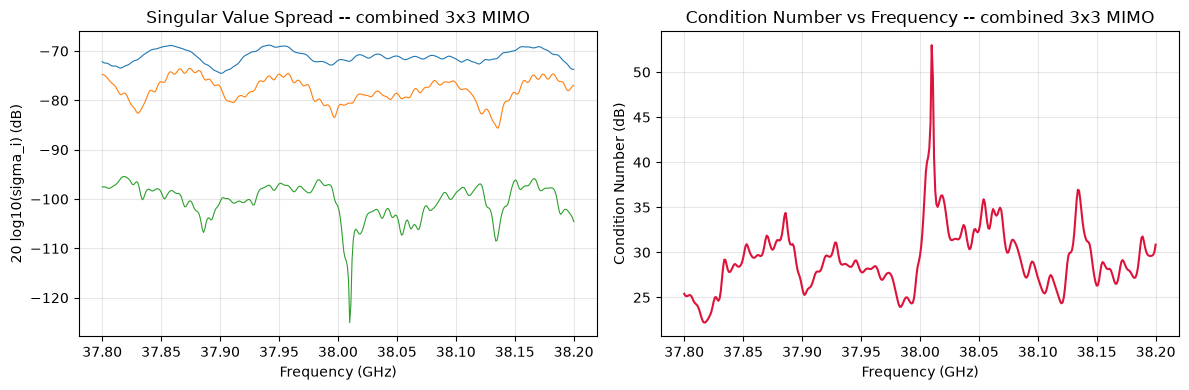

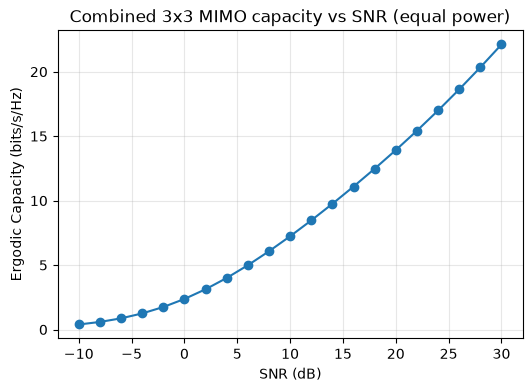

In [22]:
if SHOW_MIMO_PLOTS:
    f_ghz = freqs_ref / 1e9

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for i in range(svs.shape[1]):
        ax[0].plot(f_ghz, 20 * np.log10(svs[:, i] + 1e-15), lw=0.8)
    ax[0].set_xlabel("Frequency (GHz)")
    ax[0].set_ylabel(r"20 log10(sigma_i) (dB)")
    ax[0].set_title("Singular Value Spread -- combined 3x3 MIMO")
    ax[0].grid(alpha=0.3)

    ax[1].plot(f_ghz, 20 * np.log10(cond), color="crimson")
    ax[1].set_xlabel("Frequency (GHz)")
    ax[1].set_ylabel("Condition Number (dB)")
    ax[1].set_title("Condition Number vs Frequency -- combined 3x3 MIMO")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(snr_range, C_ergodic, "o-", color="tab:blue")
    plt.xlabel("SNR (dB)")
    plt.ylabel("Ergodic Capacity (bits/s/Hz)")
    plt.title("Combined 3x3 MIMO capacity vs SNR (equal power)")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("SHOW_MIMO_PLOTS=False -- plot skipped, the numeric summary is still available above.")


### 10b. Spatial correlation (decorrelation) evaluation — combined 3x3 MIMO

Measures how **decorrelated** the 3 RX-side "spatial channels" are from each other (simulation
scenario index 0..2, see the physical note in section 10), with realizations = (TX element x
frequency) combinations -- adapted directly from `Setup_20mx20m_9x9.ipynb` (`rx_correlation`).

The closer the off-diagonal correlation coefficient is to 0 = the more independent the scenarios
are, the better for diversity/multiplexing gain -- consistent with the effective rank already
computed in section 10 (erank close to 3 = good decorrelation; erank close to 1 = highly
correlated, limited MIMO capacity).


In [23]:
def rx_correlation_3x3(H9):
    """RX-side spatial correlation for the combined 3x3 MIMO matrix. Realization samples =
    (TX element x frequency) combinations. R = E[h h^H], normalized into a correlation
    coefficient (diag = 1). Adapted directly from Setup_20mx20m_9x9.ipynb."""
    n_rx = H9.shape[0]
    X = H9.reshape(n_rx, -1)          # [3, 3*n_f] -- each column = 1 realization of the rx vector
    R = (X @ X.conj().T) / X.shape[1]
    d = np.sqrt(np.real(np.diag(R)))
    return R / np.outer(d, d)


R_rx_3x3 = rx_correlation_3x3(H_3x3)
_offdiag_3x3 = R_rx_3x3[~np.eye(H_3x3.shape[0], dtype=bool)]

print("=" * 60)
print("SPATIAL CORRELATION (DECORRELATION) -- combined 3x3 MIMO, RX side")
print("=" * 60)
print(f"Mean |rho| off-diagonal : {np.mean(np.abs(_offdiag_3x3)):.4f}")
print(f"Max  |rho| off-diagonal : {np.max(np.abs(_offdiag_3x3)):.4f}")
print("(closer to 0 = more decorrelated/independent -- good for diversity/multiplexing gain; "
      "closer to 1 = more correlated, limiting effective rank & MIMO capacity)")


SPATIAL CORRELATION (DECORRELATION) -- combined 3x3 MIMO, RX side
Mean |rho| off-diagonal : 0.5636
Max  |rho| off-diagonal : 0.7449
(closer to 0 = more decorrelated/independent -- good for diversity/multiplexing gain; closer to 1 = more correlated, limiting effective rank & MIMO capacity)


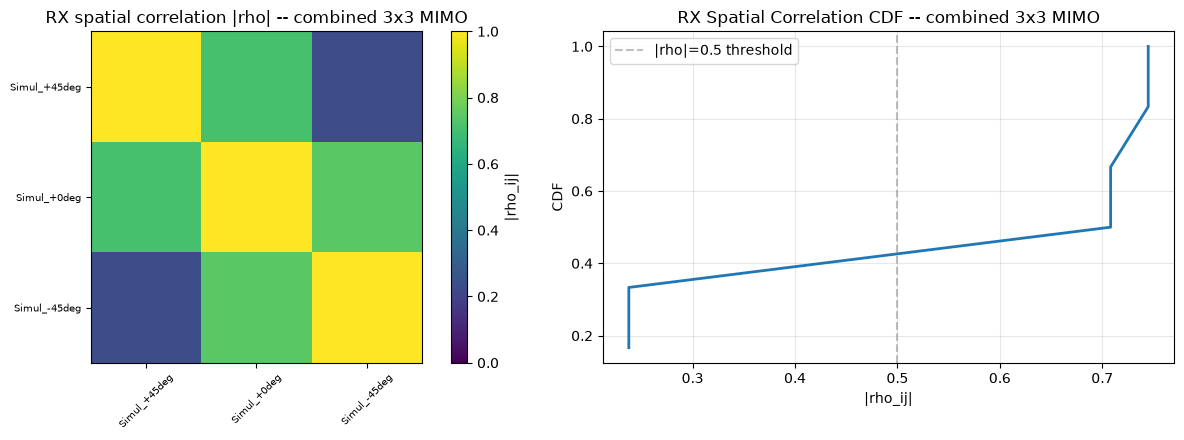

In [24]:
if SHOW_MIMO_PLOTS:
    _labels_3x3 = [cfg["name"] for cfg in SIMULATION_CONFIGS]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

    im = ax[0].imshow(np.abs(R_rx_3x3), vmin=0, vmax=1, cmap="viridis")
    ax[0].set_xticks(range(len(_labels_3x3))); ax[0].set_xticklabels(_labels_3x3, rotation=45, fontsize=7)
    ax[0].set_yticks(range(len(_labels_3x3))); ax[0].set_yticklabels(_labels_3x3, fontsize=7)
    ax[0].set_title("RX spatial correlation |rho| -- combined 3x3 MIMO")
    plt.colorbar(im, ax=ax[0], label=r"|rho_ij|")

    vals = np.sort(np.abs(_offdiag_3x3))
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax[1].plot(vals, cdf, lw=2)
    ax[1].axvline(0.5, color="gray", ls="--", alpha=0.5, label=r"|rho|=0.5 threshold")
    ax[1].set_xlabel(r"|rho_ij|")
    ax[1].set_ylabel("CDF")
    ax[1].set_title("RX Spatial Correlation CDF -- combined 3x3 MIMO")
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("SHOW_MIMO_PLOTS=False -- correlation plot skipped, the numeric summary is still available above.")


## Notes & further TODOs

1. **Fill in the actual numbers** in the "CONFIGURATION — EDIT HERE" cell: `TX_POSITIONS`,
   `TX_ORIENTATION_DEG` (the real TX array geometry), `TX_CUSTOM_CSV` (if TX isn't omni -- fill it
   in once you have the CSV file, then set `TX_PATTERN_MODE = "csv"`), and each
   `SIMULATION_CONFIGS` entry (RX position/orientation + `rx_farfield_csv`/
   `rx_farfield_param_filters` per scenario -- change to any CSV you want, not tied to these 3
   default lens angles). The current values are just placeholders so the notebook can run
   end-to-end as a sanity check.
2. **Mirroring assumption** (if still using the default): the positive RX lens angles
   (+15/+30/+45/+60°) are built from the mirrored negative file (`Phi -> -Phi`), generated once in
   the section 4 cell (`lens_csv_for_angle`). If real HFSS data for the positive side becomes
   available later, just change `rx_farfield_csv` in the config to the real file's path.
3. **`TX_CUSTOM_CSV`**: if TX isn't omni, fill in the CSV path in the configuration cell and set
   `TX_PATTERN_MODE = "csv"` -- this pattern is used the same for all 3 TX elements (not
   per-element, since TX doesn't use a lens).
4. **Compute cost**: the main loop is now only 3 `PathSolver` runs (one per RX scenario, with 3
   simultaneous TX in each run) -- much cheaper than 9 per-element runs. Default
   `samples_per_src=1_000_000`; lower it first if you just want a quick sanity check.
5. The evaluation methodology (correlation, capacity) is adapted from `Setup_20mx20m_9x9.ipynb`.
   The correlation between the 3 TX elements here is **real and simultaneous** (one scene, one
   run) for each RX scenario; what is **not** simultaneous is across the 3 RX scenarios themselves
   (RX position/orientation/lens are tested one at a time, not 3 active RX at once).
6. **Want to experiment with RX position/orientation/CSV before putting it into
   `SIMULATION_CONFIGS`?** Use `Sandbox_TuningRX_Lens9x9.ipynb` (a separate notebook, in the same
   folder) -- lets you iterate quickly (without `PathSolver`) while viewing the 3D beam-direction
   plot, then manually copy the result here once it's right.
7. **Plot toggles (`SHOW_ANTENNA_PROFILE_PLOTS`/`SHOW_POWER_PLOTS`/`SHOW_RAY_PREVIEW`/
   `SHOW_MIMO_PLOTS`)**: purely for speeding up iteration (skip rendering if you just want to check
   the numbers) -- during development there was a mistaken suspicion that matplotlib/`np.linalg`/
   `@` "crash" in this environment; it turned out to just be an artifact of how automated testing
   was done (a Python subprocess invoked without the `Library/bin` env on its PATH, so the
   MKL/BLAS DLL failed to load) -- not a real bug, and it doesn't happen in your usual Jupyter/VS
   Code session. The 3x3 MIMO metrics (section 10) have accordingly also been simplified back to
   plain `np.linalg.svd` (not a manual solver).


## 11. TX user bergerak linear di dalam ruangan

Bagian ini menggantikan eksperimen Random-TX Monte Carlo. Satu **TX user** membawa array patch
3 elemen dan bergerak linear pada **X=0 m**, dari **Y=-10 m sampai Y=+10 m**, sesuai `TRAJECTORY_START_M` dan `TRAJECTORY_END_M`.
Geometri relatif antar-elemen tidak berubah; titik trajectory menyatakan pusat array TX.

Pada setiap waypoint, posisi yang sama diuji terhadap seluruh 3 skenario lens RX. Karena itu total
`PathSolver` run = `N_TRAJECTORY_POINTS × len(SIMULATION_CONFIGS)`. Urutan waypoint juga dapat
diubah menjadi waktu melalui `TRAJECTORY_SPEED_M_S`.

Metric yang disimpan meliputi posisi/waktu, jarak TX-RX, received power, SNR, capacity, throughput,
frequency outage, dan RMS delay spread. Section 11c tetap mengevaluasi conditioning matriks 3×3,
tetapi sekarang per waypoint sepanjang trajectory.

**Mobility Sionna RT:** setiap TX diberi `Transmitter.velocity`. Pada tiap waypoint,
`Paths.cfr()` dipanggil dengan `sampling_frequency` dan `num_time_steps`, sehingga fase kanal
berevolusi berdasarkan Doppler native Sionna RT. Geometry/path loss tetap diperbarui per waypoint.

In [25]:
# --- Parameter lintasan linear TX user (edit di sini) ---
RUN_LINEAR_TX_TRAJECTORY = True
TRAJECTORY_START_M = [0.0, -9.5, 2.0]  # pusat array pada waypoint pertama [x, y, z]
TRAJECTORY_END_M   = [0.0,  9.5, 2.0]  # pusat array pada waypoint terakhir [x, y, z]
N_TRAJECTORY_POINTS = 21                 # termasuk titik awal dan akhir
TRAJECTORY_SPEED_M_S = 1.0               # hanya untuk memberi timestamp pada setiap waypoint
TRAJECTORY_RX_CONFIG_INDEX = 1           # RX referensi untuk plot jarak
TRAJECTORY_WALL_MARGIN_M = 0.0
TRAJECTORY_ARRAY_YAW_DEG = -90.0       # array melintang sumbu X saat user bergerak di Y
TRAJECTORY_PATH_SAMPLES_PER_SRC = 100_000  # naikkan ke 1_000_000 untuk hasil final
TRAJECTORY_POINT_TX_AT_RX = True          # True: patch mengikuti arah RX saat user bergerak

# Sionna RT mobility/Doppler sampling at every waypoint
MOBILITY_SAMPLING_FREQUENCY_HZ = 1000.0  # channel time-sampling rate
MOBILITY_NUM_TIME_STEPS = 16             # 16 samples = 15 ms window at 1 kHz

# Link budget
TX_POWER_DBM_PER_TX = 10.0
NOISE_FIGURE_DB = 7.0
NOISE_TEMPERATURE_K = 290.0
SNR_OUTAGE_THRESHOLD_DB = 0.0
CAPACITY_OUTAGE_THRESHOLD_BPSHZ = 1.0

trajectory_length_m = np.linalg.norm(
    np.asarray(TRAJECTORY_END_M, float) - np.asarray(TRAJECTORY_START_M, float))
print(f"Linear trajectory: {N_TRAJECTORY_POINTS} waypoint, length={trajectory_length_m:.2f} m, "
      f"duration={trajectory_length_m / TRAJECTORY_SPEED_M_S:.2f} s, "
      f"{N_TRAJECTORY_POINTS * len(SIMULATION_CONFIGS)} total PathSolver runs")

Linear trajectory: 21 waypoint, length=19.00 m, duration=19.00 s, 63 total PathSolver runs


In [26]:
def linear_tx_trajectory(start, end, n_points, element_positions=TX_POSITIONS,
                         room_x=ROOM_X, room_y=ROOM_Y, room_z=ROOM_Z,
                         wall_margin=TRAJECTORY_WALL_MARGIN_M):
    """Return waypoint centers and rigid 3-element TX positions along a straight line."""
    if n_points < 2:
        raise ValueError("N_TRAJECTORY_POINTS must be at least 2.")
    start, end = np.asarray(start, float), np.asarray(end, float)
    centers = np.linspace(start, end, n_points)

    # TX_POSITIONS defines the rigid array geometry; only offsets from its centroid are retained.
    base = np.asarray(element_positions, float)
    offsets = base - base.mean(axis=0, keepdims=True)

    # Rotate the rigid array around Z. For the requested Y-axis trajectory, -90 degrees turns
    # the original Y-oriented element line into X, keeping all elements inside the room even
    # when the TX-user center reaches Y=-10 m or Y=+10 m.
    yaw = np.deg2rad(TRAJECTORY_ARRAY_YAW_DEG)
    rotation_z = np.array([[np.cos(yaw), -np.sin(yaw), 0.0],
                           [np.sin(yaw),  np.cos(yaw), 0.0],
                           [0.0,          0.0,         1.0]])
    offsets = offsets @ rotation_z.T
    positions = centers[:, None, :] + offsets[None, :, :]

    lower = np.array([-room_x / 2 + wall_margin, -room_y / 2 + wall_margin, wall_margin])
    upper = np.array([ room_x / 2 - wall_margin,  room_y / 2 - wall_margin,
                       room_z - wall_margin])
    if np.any(positions < lower - 1e-9) or np.any(positions > upper + 1e-9):
        bad = np.argwhere(np.any((positions < lower - 1e-9) | (positions > upper + 1e-9), axis=2))[0]
        raise ValueError(f"TX element exits room at waypoint={bad[0]}, element={bad[1]}; "
                         "adjust start/end or wall margin.")
    return centers, positions


def build_trajectory_tx_scene(tx_positions, tx_pattern_name, cfg, tx_velocity,
                              rx_pattern_name="hfss_rx", xml_path=ROOM_XML):
    """Build one waypoint scene for the rigid TX-user array and one RX lens scenario."""
    scene = load_scene(xml_path)
    scene.frequency = F_C
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern=tx_pattern_name,
                                 polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern=rx_pattern_name,
                                 polarization="V")
    rx_position = [float(v) for v in cfg["rx_position"]]
    tx_orientation = mi.Point3f(*[float(v) for v in np.deg2rad(TX_ORIENTATION_DEG)])
    for k, position in enumerate(tx_positions):
        tx = Transmitter(f"tx{k}", position=[float(v) for v in position],
                         orientation=tx_orientation, display_radius=0.15)
        # Native Sionna RT mobility: velocity is used by Paths.cfr() to compute Doppler.
        tx.velocity = mi.Vector3f(*[float(v) for v in tx_velocity])
        scene.add(tx)
        if TRAJECTORY_POINT_TX_AT_RX:
            tx.look_at(rx_position)
    rx = Receiver("rx", position=rx_position,
                  orientation=mi.Point3f(*[float(v) for v in
                                           np.deg2rad(cfg["rx_orientation_deg"])]),
                  display_radius=0.15)
    scene.add(rx)
    return scene


def compute_H_with_mobility(scene, f_c=F_C, bw=BW, n_f=N_F, max_depth=3,
                            samples_per_src=1_000_000,
                            sampling_frequency=MOBILITY_SAMPLING_FREQUENCY_HZ,
                            num_time_steps=MOBILITY_NUM_TIME_STEPS):
    """Compute geometry paths plus native Sionna RT Doppler-based CFR time evolution.

    Returns
    -------
    H_snapshot : [n_tx, n_freq]
        First mobility time sample, compatible with the existing per-waypoint/MIMO analysis.
    H_time : [n_tx, n_time, n_freq]
        Native Sionna RT time-varying CFR from Paths.cfr().
    """
    solver = PathSolver()
    paths = solver(
        scene, max_depth=max_depth, samples_per_src=samples_per_src,
        los=True, specular_reflection=True, diffuse_reflection=False,
        refraction=False, synthetic_array=True,
    )
    freqs = np.linspace(f_c - bw / 2, f_c + bw / 2, n_f)
    h_time = paths.cfr(
        frequencies=mi.Float(freqs),
        sampling_frequency=float(sampling_frequency),
        num_time_steps=int(num_time_steps),
        normalize_delays=False,
        out_type="numpy",
    )
    h_time = np.asarray(np.squeeze(h_time))
    if h_time.ndim == 1:                         # one TX, one time sample
        h_time = h_time[None, None, :]
    elif h_time.ndim == 2:
        if num_time_steps == 1:                 # [n_tx, n_freq]
            h_time = h_time[:, None, :]
        else:                                   # one TX: [n_time, n_freq]
            h_time = h_time[None, :, :]
    H_snapshot = h_time[:, 0, :]
    return H_snapshot, h_time, freqs, paths


def trajectory_channel_metrics(Hf, freqs, tx_power_dbm=TX_POWER_DBM_PER_TX,
                               noise_figure_db=NOISE_FIGURE_DB,
                               temperature_k=NOISE_TEMPERATURE_K):
    """Compute absolute link-budget metrics without normalizing channel amplitude."""
    h_power = np.abs(Hf) ** 2
    tx_power_w = 10 ** ((tx_power_dbm - 30.0) / 10.0)
    noise_power_w = 1.380649e-23 * temperature_k * BW * 10 ** (noise_figure_db / 10.0)
    rx_power_w_f = tx_power_w * np.sum(h_power, axis=0)
    snr_f = rx_power_w_f / noise_power_w
    capacity_f = np.log2(1.0 + snr_f)

    impulse = np.fft.ifft(Hf, axis=1)
    pdp = np.sum(np.abs(impulse) ** 2, axis=0)
    delay_s = np.arange(Hf.shape[1]) / (Hf.shape[1] * np.mean(np.diff(freqs)))
    pdp_sum = np.sum(pdp)
    if pdp_sum > 0:
        mean_delay_s = np.sum(delay_s * pdp) / pdp_sum
        rms_delay_s = np.sqrt(np.sum((delay_s - mean_delay_s) ** 2 * pdp) / pdp_sum)
    else:
        rms_delay_s = np.nan
    channel_magnitude_db = 20 * np.log10(np.abs(Hf) + 1e-30)
    return {
        # Statistics of the raw complex channel H(f), across TX elements and frequencies.
        "mean_channel_magnitude_db": np.mean(channel_magnitude_db),
        "p05_channel_magnitude_db": np.percentile(channel_magnitude_db, 5),
        "p95_channel_magnitude_db": np.percentile(channel_magnitude_db, 95),
        "mean_rx_power_dbm": 10 * np.log10(np.mean(rx_power_w_f) / 1e-3 + 1e-30),
        "mean_snr_db": 10 * np.log10(np.mean(snr_f) + 1e-30),
        "p05_snr_db": np.percentile(10 * np.log10(snr_f + 1e-30), 5),
        "capacity_bits_s_hz": np.mean(capacity_f),
        "throughput_gbps": BW * np.mean(capacity_f) / 1e9,
        "freq_outage_probability": np.mean(
            10 * np.log10(snr_f + 1e-30) < SNR_OUTAGE_THRESHOLD_DB),
        "rms_delay_spread_ns": rms_delay_s * 1e9,
    }

In [27]:
trajectory_results = pd.DataFrame()
trajectory_centers = np.empty((0, 3))
trajectory_tx_positions_all = np.empty((0, len(TX_POSITIONS), 3))
trajectory_H_all = []  # first mobility time sample per waypoint
trajectory_H_time_all = []  # native Sionna CFR: (rx, tx, time, frequency)
freqs_ref_trajectory = None

if RUN_LINEAR_TX_TRAJECTORY:
    trajectory_centers, trajectory_tx_positions_all = linear_tx_trajectory(
        TRAJECTORY_START_M, TRAJECTORY_END_M, N_TRAJECTORY_POINTS)
    step_distance = np.r_[0.0, np.linalg.norm(np.diff(trajectory_centers, axis=0), axis=1)]
    distance_along = np.cumsum(step_distance)
    time_s = distance_along / TRAJECTORY_SPEED_M_S

    tx_pattern_trajectory = "iso" if TX_PATTERN_MODE == "iso" else "hfss_tx"
    direction = np.asarray(TRAJECTORY_END_M, float) - np.asarray(TRAJECTORY_START_M, float)
    tx_velocity = TRAJECTORY_SPEED_M_S * direction / np.linalg.norm(direction)
    print(f"Sionna mobility velocity = {np.round(tx_velocity, 3)} m/s; "
          f"CFR window={(MOBILITY_NUM_TIME_STEPS - 1) / MOBILITY_SAMPLING_FREQUENCY_HZ * 1e3:.1f} ms")
    n_rx_cfg = len(SIMULATION_CONFIGS)
    n_tx = len(TX_POSITIONS)
    rows = []

    for waypoint, positions in enumerate(trajectory_tx_positions_all):
        H_waypoint = np.zeros((n_rx_cfg, n_tx, N_F), dtype=complex)
        H_time_waypoint = np.zeros(
            (n_rx_cfg, n_tx, MOBILITY_NUM_TIME_STEPS, N_F), dtype=complex)
        for rx_i, rx_cfg in enumerate(SIMULATION_CONFIGS):
            register_antenna_pattern("hfss_rx_trajectory", make_hfss_factory(
                rx_cfg["rx_farfield_csv"], freq_ghz=FREQ_GHZ,
                param_filters=rx_cfg["rx_farfield_param_filters"], rot_deg=HFSS_ROT_DEG))
            scene_trajectory = build_trajectory_tx_scene(
                positions, tx_pattern_trajectory, rx_cfg, tx_velocity,
                rx_pattern_name="hfss_rx_trajectory")
            Hf, Hf_time, freqs, paths_mobility = compute_H_with_mobility(
                scene_trajectory, f_c=F_C, bw=BW, n_f=N_F,
                samples_per_src=TRAJECTORY_PATH_SAMPLES_PER_SRC)
            freqs_ref_trajectory = freqs
            H_waypoint[rx_i] = Hf
            H_time_waypoint[rx_i] = Hf_time

            metrics = trajectory_channel_metrics(Hf, freqs)
            magnitude_time_db = 20 * np.log10(np.abs(Hf_time) + 1e-30)
            mean_per_time_db = magnitude_time_db.mean(axis=(0, 2))
            metrics["mean_channel_magnitude_db"] = magnitude_time_db.mean()
            metrics["p05_channel_magnitude_db"] = np.percentile(magnitude_time_db, 5)
            metrics["p95_channel_magnitude_db"] = np.percentile(magnitude_time_db, 95)
            metrics["mobility_channel_std_db"] = np.std(mean_per_time_db)
            metrics.update({
                "waypoint": waypoint, "distance_along_m": distance_along[waypoint],
                "time_s": time_s[waypoint], "tx_center_x_m": trajectory_centers[waypoint, 0],
                "tx_center_y_m": trajectory_centers[waypoint, 1],
                "tx_center_z_m": trajectory_centers[waypoint, 2],
                "rx_config_index": rx_i, "rx_config_name": rx_cfg["name"],
                "rx_lens_angle_deg": rx_cfg["rx_lens_angle_deg"],
                "center_tx_rx_distance_m": np.linalg.norm(
                    trajectory_centers[waypoint] - np.asarray(rx_cfg["rx_position"])),
            })
            rows.append(metrics)
            print(f"WP {waypoint + 1:02d}/{N_TRAJECTORY_POINTS} "
                  f"d={distance_along[waypoint]:.2f} m RX={rx_cfg['name']:>12s}: "
                  f"SNR={metrics['mean_snr_db']:.1f} dB, "
                  f"C={metrics['capacity_bits_s_hz']:.2f} bit/s/Hz")
        trajectory_H_all.append(H_waypoint)
        trajectory_H_time_all.append(H_time_waypoint)

    trajectory_results = pd.DataFrame(rows).sort_values(
        ["waypoint", "rx_config_index"]).reset_index(drop=True)

trajectory_results

Sionna mobility velocity = [0. 1. 0.] m/s; CFR window=15.0 ms
WP 01/21 d=0.00 m RX=Simul_+45deg: SNR=6.2 dB, C=2.26 bit/s/Hz
WP 01/21 d=0.00 m RX= Simul_+0deg: SNR=5.0 dB, C=1.96 bit/s/Hz
WP 01/21 d=0.00 m RX=Simul_-45deg: SNR=20.4 dB, C=6.71 bit/s/Hz
WP 02/21 d=0.95 m RX=Simul_+45deg: SNR=6.2 dB, C=2.27 bit/s/Hz
WP 02/21 d=0.95 m RX= Simul_+0deg: SNR=5.4 dB, C=2.04 bit/s/Hz
WP 02/21 d=0.95 m RX=Simul_-45deg: SNR=21.7 dB, C=7.20 bit/s/Hz
WP 03/21 d=1.90 m RX=Simul_+45deg: SNR=6.8 dB, C=2.39 bit/s/Hz
WP 03/21 d=1.90 m RX= Simul_+0deg: SNR=7.3 dB, C=2.52 bit/s/Hz
WP 03/21 d=1.90 m RX=Simul_-45deg: SNR=23.5 dB, C=7.82 bit/s/Hz
WP 04/21 d=2.85 m RX=Simul_+45deg: SNR=7.2 dB, C=2.51 bit/s/Hz
WP 04/21 d=2.85 m RX= Simul_+0deg: SNR=7.0 dB, C=2.45 bit/s/Hz
WP 04/21 d=2.85 m RX=Simul_-45deg: SNR=24.7 dB, C=8.21 bit/s/Hz
WP 05/21 d=3.80 m RX=Simul_+45deg: SNR=7.2 dB, C=2.50 bit/s/Hz
WP 05/21 d=3.80 m RX= Simul_+0deg: SNR=10.7 dB, C=3.54 bit/s/Hz
WP 05/21 d=3.80 m RX=Simul_-45deg: SNR=24.8 dB, C=8

,mean_channel_magnitude_db,p05_channel_magnitude_db,p95_channel_magnitude_db,mean_rx_power_dbm,mean_snr_db,p05_snr_db,capacity_bits_s_hz,throughput_gbps,freq_outage_probability,rms_delay_spread_ns,...,waypoint,distance_along_m,time_s,tx_center_x_m,tx_center_y_m,tx_center_z_m,rx_config_index,rx_config_name,rx_lens_angle_deg,center_tx_rx_distance_m
0,-91.997269,-102.304260,-85.010124,-74.779953,6.174634,1.322300,2.258436,0.903374,0.014963,53.041110,...,0,0.00,0.00,0.0,-9.50,2.0,0,Simul_+45deg,45,13.085804
1,-93.021210,-102.970306,-86.187134,-75.955818,4.998771,-0.087312,1.958338,0.783335,0.054863,51.800604,...,0,0.00,0.00,0.0,-9.50,2.0,1,Simul_+0deg,0,13.097950
2,-76.110313,-81.536751,-72.349525,-60.516998,20.437592,17.145809,6.713341,2.685337,0.000000,45.335641,...,0,0.00,0.00,0.0,-9.50,2.0,2,Simul_-45deg,-45,13.103246
3,-91.693108,-101.853958,-85.141098,-74.717476,6.237109,1.366992,2.267155,0.906862,0.027431,53.677100,...,1,0.95,0.95,0.0,-8.55,2.0,0,Simul_+45deg,45,12.414250
4,-92.958153,-103.296936,-85.773750,-75.511795,5.442792,0.487152,2.036032,0.814413,0.039900,54.742121,...,1,0.95,0.95,0.0,-8.55,2.0,1,Simul_+0deg,0,12.426133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,-92.920593,-103.137505,-86.353645,-75.746437,5.208150,-0.235324,1.985052,0.794021,0.057357,53.813107,...,19,18.05,18.05,0.0,8.55,2.0,1,Simul_+0deg,0,12.426133
59,-91.594688,-101.819878,-84.880615,-74.603210,6.351373,1.295096,2.292136,0.916854,0.022444,53.917515,...,19,18.05,18.05,0.0,8.55,2.0,2,Simul_-45deg,-45,12.414250
60,-76.299751,-81.670883,-72.658081,-60.756336,20.198252,16.943905,6.635368,2.654147,0.000000,45.727222,...,20,19.00,19.00,0.0,9.50,2.0,0,Simul_+45deg,45,13.103246
61,-93.067719,-103.231903,-86.147232,-75.859993,5.094595,0.041920,1.981367,0.792547,0.049875,52.655976,...,20,19.00,19.00,0.0,9.50,2.0,1,Simul_+0deg,0,13.097950


### 11b. Visualisasi lintasan dan data channel TX user

Plot pertama memperlihatkan lintasan geometris TX user. Setelah simulasi selesai, panel channel
menampilkan magnitude mentah $20\log_{10}|H(f)|$, received power, SNR, capacity, dan RMS delay
spread sepanjang trajectory. Setiap konfigurasi lens RX dibedakan menggunakan **warna dan marker**
agar kurva yang berimpit tetap dapat dikenali.

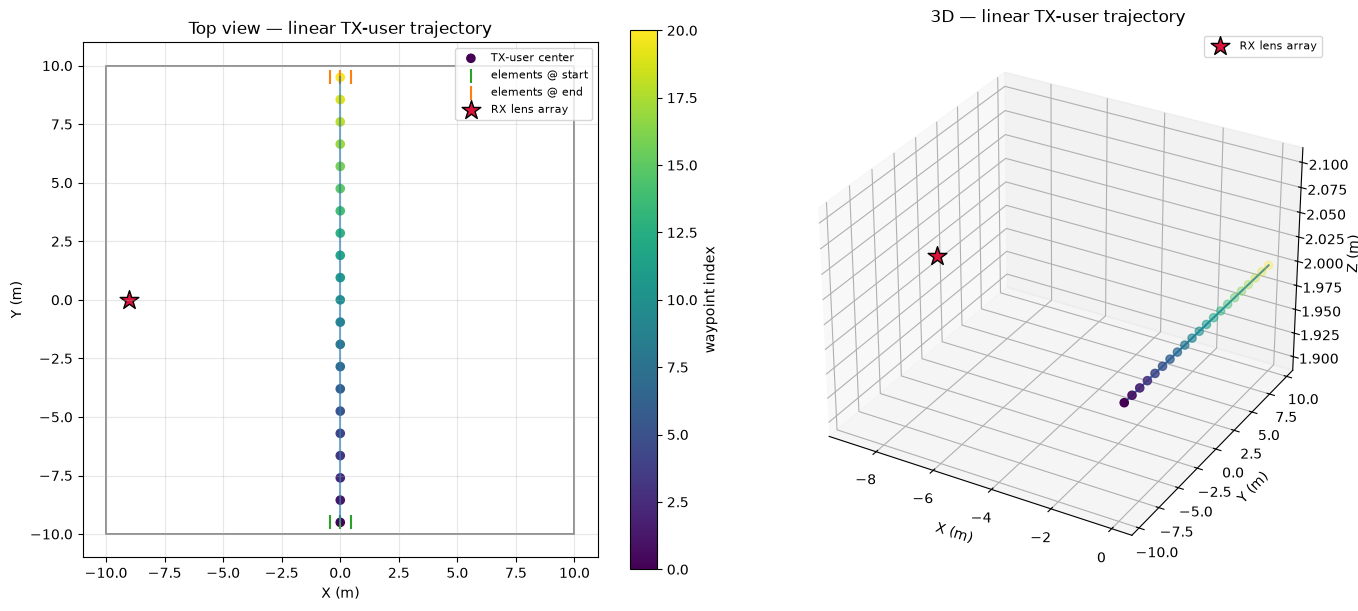

Start center : [ 0.  -9.5  2. ] m
End center   : [0.  9.5 2. ] m
Path length  : 19.000 m


In [28]:
def plot_linear_tx_trajectory(centers, tx_positions, rx_position,
                              room_x=ROOM_X, room_y=ROOM_Y, room_z=ROOM_Z,
                              figsize=(14, 6)):
    centers, tx_positions = np.asarray(centers), np.asarray(tx_positions)
    rx = np.asarray(rx_position, float)
    hx, hy = room_x / 2, room_y / 2
    idx = np.arange(len(centers))
    fig = plt.figure(figsize=figsize)

    ax0 = fig.add_subplot(1, 2, 1)
    ax0.add_patch(plt.Rectangle((-hx, -hy), room_x, room_y, fill=False,
                                edgecolor="gray", lw=1.2))
    ax0.plot(centers[:, 0], centers[:, 1], color="tab:blue", alpha=0.6)
    sc = ax0.scatter(centers[:, 0], centers[:, 1], c=idx, cmap="viridis", s=35,
                     label="TX-user center")
    ax0.scatter(tx_positions[0, :, 0], tx_positions[0, :, 1], marker="|", s=100,
                color="tab:green", label="elements @ start")
    ax0.scatter(tx_positions[-1, :, 0], tx_positions[-1, :, 1], marker="|", s=100,
                color="tab:orange", label="elements @ end")
    ax0.scatter(rx[0], rx[1], marker="*", s=200, color="crimson", edgecolor="black",
                label="RX lens array")
    ax0.set(xlabel="X (m)", ylabel="Y (m)", title="Top view — linear TX-user trajectory")
    ax0.set_aspect("equal"); ax0.grid(alpha=0.3); ax0.legend(fontsize=8)
    fig.colorbar(sc, ax=ax0, label="waypoint index")

    ax1 = fig.add_subplot(1, 2, 2, projection="3d")
    ax1.plot(centers[:, 0], centers[:, 1], centers[:, 2], color="tab:blue")
    ax1.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c=idx, cmap="viridis", s=35)
    ax1.scatter(rx[0], rx[1], rx[2], marker="*", s=200, color="crimson",
                edgecolor="black", label="RX lens array")
    ax1.set(xlabel="X (m)", ylabel="Y (m)", zlabel="Z (m)",
            title="3D — linear TX-user trajectory")
    ax1.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(f"Start center : {np.round(centers[0], 3)} m")
    print(f"End center   : {np.round(centers[-1], 3)} m")
    print(f"Path length  : {np.sum(np.linalg.norm(np.diff(centers, axis=0), axis=1)):.3f} m")


if len(trajectory_centers):
    plot_linear_tx_trajectory(
        trajectory_centers, trajectory_tx_positions_all,
        SIMULATION_CONFIGS[TRAJECTORY_RX_CONFIG_INDEX]["rx_position"])
else:
    print("Trajectory kosong — aktifkan RUN_LINEAR_TX_TRAJECTORY dan jalankan cell 11.")

LINEAR TX-USER TRAJECTORY — CHANNEL SUMMARY
Waypoints / RX scenarios / total runs : 21 / 3 / 63
Path length / duration                 : 19.00 m / 19.00 s
Channel magnitude median               : -86.75 dB
Capacity median                        : 3.57 bit/s/Hz
Trajectory-RX outage                   : 0.0%

Per RX scenario:
  rx_config_index rx_config_name  rx_lens_angle_deg  capacity_median  capacity_min  channel_magnitude_median_db  snr_median_db  outage
               0   Simul_+45deg                 45         3.612021      2.258436                   -86.491104      10.956356     0.0
               1    Simul_+0deg                  0         3.536730      1.958338                   -86.854622      10.702959     0.0
               2   Simul_-45deg                -45         3.552169      2.292136                   -86.745621      10.906945     0.0


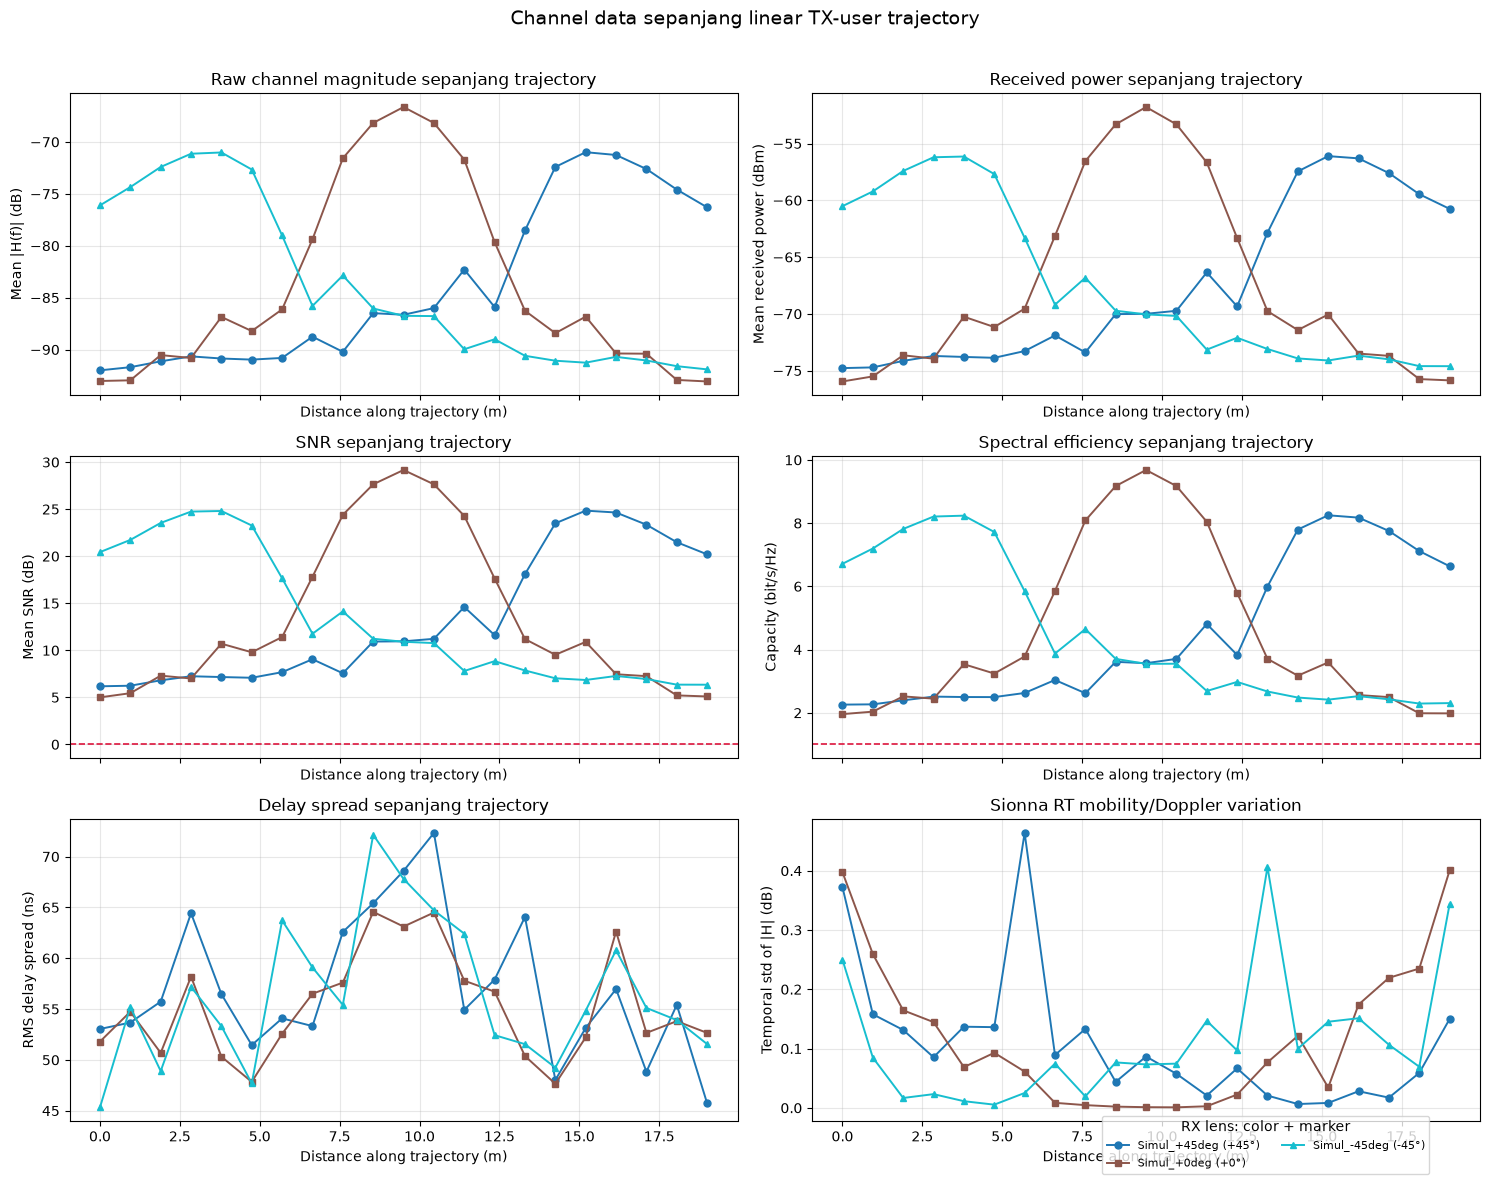

In [29]:
if RUN_LINEAR_TX_TRAJECTORY and not trajectory_results.empty:
    capacity_outage = np.mean(
        trajectory_results["capacity_bits_s_hz"] < CAPACITY_OUTAGE_THRESHOLD_BPSHZ)
    per_rx = trajectory_results.groupby(
        ["rx_config_index", "rx_config_name", "rx_lens_angle_deg"]
    ).agg(capacity_median=("capacity_bits_s_hz", "median"),
          capacity_min=("capacity_bits_s_hz", "min"),
          channel_magnitude_median_db=("mean_channel_magnitude_db", "median"),
          snr_median_db=("mean_snr_db", "median"),
          outage=("capacity_bits_s_hz",
                  lambda s: np.mean(s < CAPACITY_OUTAGE_THRESHOLD_BPSHZ))).reset_index()

    print("=" * 72)
    print("LINEAR TX-USER TRAJECTORY — CHANNEL SUMMARY")
    print("=" * 72)
    print(f"Waypoints / RX scenarios / total runs : {N_TRAJECTORY_POINTS} / "
          f"{len(SIMULATION_CONFIGS)} / {len(trajectory_results)}")
    print(f"Path length / duration                 : {trajectory_length_m:.2f} m / "
          f"{trajectory_length_m / TRAJECTORY_SPEED_M_S:.2f} s")
    print(f"Channel magnitude median               : "
          f"{trajectory_results['mean_channel_magnitude_db'].median():.2f} dB")
    print(f"Capacity median                        : "
          f"{trajectory_results['capacity_bits_s_hz'].median():.2f} bit/s/Hz")
    print(f"Trajectory-RX outage                   : {100 * capacity_outage:.1f}%")
    print("\nPer RX scenario:\n", per_rx.to_string(index=False))

    # Color AND marker encode the RX-lens scenario. This remains distinguishable when curves
    # overlap or the figure is printed without color.
    n_scenarios = len(SIMULATION_CONFIGS)
    colors = plt.cm.tab10(np.linspace(0, 1, n_scenarios))
    markers = ["o", "s", "^", "D", "v", "P", "X", "<", ">"]

    plot_specs = [
        ("mean_channel_magnitude_db", "Mean |H(f)| (dB)",
         "Raw channel magnitude sepanjang trajectory"),
        ("mean_rx_power_dbm", "Mean received power (dBm)",
         "Received power sepanjang trajectory"),
        ("mean_snr_db", "Mean SNR (dB)", "SNR sepanjang trajectory"),
        ("capacity_bits_s_hz", "Capacity (bit/s/Hz)",
         "Spectral efficiency sepanjang trajectory"),
        ("rms_delay_spread_ns", "RMS delay spread (ns)",
         "Delay spread sepanjang trajectory"),
        ("mobility_channel_std_db", "Temporal std of |H| (dB)",
         "Sionna RT mobility/Doppler variation"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharex=True)
    axes = axes.ravel()
    for rx_i, (color, marker) in enumerate(zip(colors, markers)):
        sub = trajectory_results[trajectory_results["rx_config_index"] == rx_i]
        label = f"{sub['rx_config_name'].iloc[0]} ({sub['rx_lens_angle_deg'].iloc[0]:+d}°)"
        for ax, (column, ylabel, title) in zip(axes, plot_specs):
            ax.plot(sub["distance_along_m"], sub[column], color=color, marker=marker,
                    markersize=5, markevery=1, linewidth=1.4, label=label)
            ax.set(ylabel=ylabel, title=title)

    # Add threshold references only to their matching channel panels.
    axes[2].axhline(SNR_OUTAGE_THRESHOLD_DB, color="crimson", ls="--", lw=1.2,
                    label="SNR outage threshold")
    axes[3].axhline(CAPACITY_OUTAGE_THRESHOLD_BPSHZ, color="crimson", ls="--", lw=1.2,
                    label="Capacity outage threshold")

    for ax in axes:
        ax.set_xlabel("Distance along trajectory (m)")
        ax.grid(alpha=0.3)

    # One shared legend prevents six repeated legends from covering channel traces.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.96, 0.08),
               fontsize=8, ncol=2, title="RX lens: color + marker")
    fig.suptitle("Channel data sepanjang linear TX-user trajectory", fontsize=14)
    plt.tight_layout(rect=[0, 0.08, 1, 0.97])
    plt.show()

### 11c. Conditioning 3×3 MIMO sepanjang trajectory

Metric SVD, condition number, effective rank, dan capacity dihitung pada setiap waypoint dari
`trajectory_H_all[waypoint]`. Dengan demikian perubahan conditioning dapat dilihat sebagai fungsi
jarak/waktu, bukan sebagai distribusi random-drop. Seperti Section 10, kombinasi 9 lens RX ini
merupakan synthetic comparison karena pengukurannya tidak berlangsung simultan.

 waypoint  distance_along_m  time_s  cond_median  cond_median_db  erank_median  capacity_10db
        0              0.00    0.00    20.335369       26.165041      1.146537       5.817079
        1              0.95    0.95    18.135687       25.170680      1.154247       5.851070
        2              1.90    1.90    18.952791       25.553464      1.138245       5.791528
        3              2.85    2.85    23.825179       27.540723      1.099360       5.572157
        4              3.80    3.80    19.882252       25.969312      1.166768       5.940128
        5              4.75    4.75    15.030643       23.539551      1.196927       6.081574
        6              5.70    5.70     8.446295       18.533325      1.527280       7.334543
        7              6.65    6.65     9.080106       19.161818      1.521463       7.243171
        8              7.60    7.60    21.023863       26.454250      1.140240       5.808178
        9              8.55    8.55    32.468203       30.22

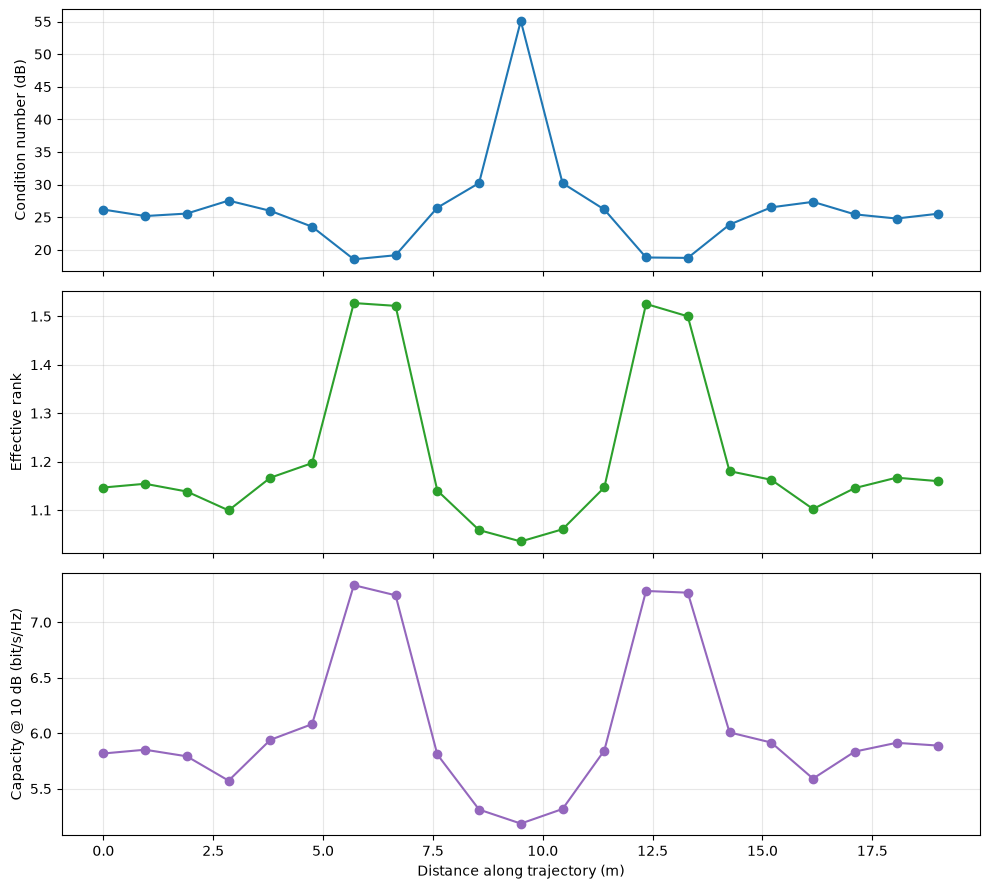

,waypoint,distance_along_m,time_s,cond_median,cond_median_db,erank_median,capacity_10db
0,0,0.00,0.00,20.335369,26.165041,1.146537,5.817079
1,1,0.95,0.95,18.135687,25.170680,1.154247,5.851070
2,2,1.90,1.90,18.952791,25.553464,1.138245,5.791528
3,3,2.85,2.85,23.825179,27.540723,1.099360,5.572157
4,4,3.80,3.80,19.882252,25.969312,1.166768,5.940128
5,5,4.75,4.75,15.030643,23.539551,1.196927,6.081574
6,6,5.70,5.70,8.446295,18.533325,1.527280,7.334543
7,7,6.65,6.65,9.080106,19.161818,1.521463,7.243171
8,8,7.60,7.60,21.023863,26.454250,1.140240,5.808178
9,9,8.55,8.55,32.468203,30.229165,1.058693,5.311655


In [30]:
trajectory_mimo_results = pd.DataFrame()

if RUN_LINEAR_TX_TRAJECTORY and trajectory_H_all:
    rows = []
    for waypoint, H_waypoint in enumerate(trajectory_H_all):
        _, cond, erank = mimo_metrics_3x3(H_waypoint)
        snr_range, capacity = mimo_capacity_3x3(H_waypoint)
        rows.append({
            "waypoint": waypoint,
            "distance_along_m": trajectory_results.loc[
                trajectory_results["waypoint"] == waypoint, "distance_along_m"].iloc[0],
            "time_s": trajectory_results.loc[
                trajectory_results["waypoint"] == waypoint, "time_s"].iloc[0],
            "cond_median": np.median(cond),
            "cond_median_db": 20 * np.log10(np.median(cond)),
            "erank_median": np.median(erank),
            "capacity_10db": capacity[np.where(snr_range == 10)[0][0]],
        })
    trajectory_mimo_results = pd.DataFrame(rows)
    print(trajectory_mimo_results.to_string(index=False))

    if SHOW_MIMO_PLOTS:
        fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
        x = trajectory_mimo_results["distance_along_m"]
        axes[0].plot(x, trajectory_mimo_results["cond_median_db"], marker="o")
        axes[0].set(ylabel="Condition number (dB)")
        axes[1].plot(x, trajectory_mimo_results["erank_median"], marker="o",
                     color="tab:green")
        axes[1].set(ylabel="Effective rank")
        axes[2].plot(x, trajectory_mimo_results["capacity_10db"], marker="o",
                     color="tab:purple")
        axes[2].set(xlabel="Distance along trajectory (m)",
                    ylabel="Capacity @ 10 dB (bit/s/Hz)")
        for ax in axes: ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()
else:
    print("trajectory_H_all kosong — jalankan loop trajectory pada Section 11 terlebih dahulu.")

trajectory_mimo_results

### Interpretasi hasil trajectory

- Gunakan sumbu `distance_along_m` atau `time_s` untuk melihat perubahan kanal saat user bergerak.
- Penurunan lokal SNR/capacity menunjukkan lokasi lintasan yang mengalami blockage, destructive
  multipath, atau mismatch dengan sudut lens RX.
- `TRAJECTORY_START_M`, `TRAJECTORY_END_M`, `N_TRAJECTORY_POINTS`, dan
  `TRAJECTORY_SPEED_M_S` adalah kontrol utama trajectory.
- Untuk final run, naikkan `TRAJECTORY_PATH_SAMPLES_PER_SRC` ke `1_000_000`. Biaya komputasi naik
  linear terhadap jumlah waypoint dan jumlah skenario RX.

## 12. Evaluasi spatial decorrelation — 1 TX × 3 RX

Evaluasi ini memilih **satu elemen TX** melalui `SPATIAL_DECORR_TX_INDEX`, kemudian membandingkan
kanal kompleks yang diterima oleh 9 konfigurasi/posisi RX sepanjang trajectory. Untuk RX ke-$i$
dan RX ke-$j$, normalized complex spatial correlation yang digunakan adalah

$$
\rho_{ij}
=
\frac{
\displaystyle\sum_{n=1}^{N} h_i[n]h_j^*[n]
}{
\sqrt{
\left(\displaystyle\sum_{n=1}^{N}|h_i[n]|^2\right)
\left(\displaystyle\sum_{n=1}^{N}|h_j[n]|^2\right)
}
}.
$$

Nilai korelasi dan dekorelasi yang dilaporkan adalah

$$
C_{ij}=|\rho_{ij}|, \qquad D_{ij}=1-|\rho_{ij}|.
$$

Dengan demikian, $C_{ij}\rightarrow1$ atau $D_{ij}\rightarrow0$ berarti kedua kanal sangat
mirip, sedangkan $C_{ij}\rightarrow0$ atau $D_{ij}\rightarrow1$ berarti kanal semakin
terdekorlasi. Diagonal memenuhi $C_{ii}=1$ dan $D_{ii}=0$.

Definisi realization:

- **Per waypoint:** $n=(t,f)$, yaitu gabungan time sample mobility dan frequency sample.
- **Keseluruhan trajectory:** $n=(w,t,f)$, yaitu waypoint, waktu, dan frekuensi digabung.

Rumus memakai CFR kompleks sehingga magnitude dan fase sama-sama berkontribusi. Tidak dilakukan
mean subtraction; ini adalah normalized channel inner product, bukan Pearson correlation pada
received power. Karena 3 RX pada notebook lens berasal dari konfigurasi/simulasi terpisah, hasil
ini harus disebut *spatial/channel-scenario decorrelation*, bukan pengukuran sembilan receiver yang
aktif simultan.

Time-varying CFR yang masuk ke rumus di atas **bukan interpolasi manual**. Pada Section 11, setiap
TX diberi velocity melalui `Transmitter.velocity`, lalu Sionna RT menghitung Doppler dan evolusi
waktu kanal melalui:

```python
paths.cfr(sampling_frequency=MOBILITY_SAMPLING_FREQUENCY_HZ,
          num_time_steps=MOBILITY_NUM_TIME_STEPS)
```

Secara konseptual, CFR mobility pada RX ke-$i$ adalah

$$
h_i(t,f)=\sum_{\ell=1}^{L}a_{i,\ell}
e^{j2\pi\nu_{i,\ell}t}e^{-j2\pi f\tau_{i,\ell}},
$$

dengan $\nu_{i,\ell}$ Doppler shift yang dihitung Sionna RT dari velocity dan arah path ke-$\ell$.
Nilai $h_i(t,f)$ inilah yang diratakan menjadi realization $n=(t,f)$ atau $n=(w,t,f)$ untuk
evaluasi spatial decorrelation.

In [31]:
# --- Spatial-decorrelation configuration ---
SPATIAL_DECORR_TX_INDEX = len(TX_POSITIONS) // 2  # center TX; valid range checked below
SPATIAL_DECORR_REQUIRE_MOBILITY = True  # reject single-time snapshot data


def spatial_correlation_matrix(H_rx_samples, eps=1e-30):
    """Return |rho| and D=1-|rho| for H shaped [n_rx, n_realizations]."""
    H = np.asarray(H_rx_samples, dtype=complex)
    if H.ndim != 2:
        raise ValueError(f"Expected H [n_rx, n_realizations], received shape={H.shape}")

    energy_norm = np.linalg.norm(H, axis=1)
    valid = energy_norm > eps
    H_normalized = np.zeros_like(H)
    H_normalized[valid] = H[valid] / energy_norm[valid, None]

    correlation_abs = np.abs(H_normalized @ H_normalized.conj().T)
    correlation_abs = np.clip(correlation_abs, 0.0, 1.0)
    invalid = ~valid
    correlation_abs[invalid, :] = np.nan
    correlation_abs[:, invalid] = np.nan
    np.fill_diagonal(correlation_abs, np.where(valid, 1.0, np.nan))
    decorrelation = 1.0 - correlation_abs
    return correlation_abs, decorrelation


def mean_off_diagonal(matrix):
    """Mean over unique RX pairs i<j, excluding the diagonal and invalid channels."""
    matrix = np.asarray(matrix, float)
    upper = matrix[np.triu_indices(matrix.shape[0], k=1)]
    return np.nanmean(upper)


spatial_correlation_overall = np.empty((0, 0))
spatial_decorrelation_overall = np.empty((0, 0))
spatial_decorrelation_trajectory = pd.DataFrame()

if not (0 <= SPATIAL_DECORR_TX_INDEX < len(TX_POSITIONS)):
    raise ValueError(f"SPATIAL_DECORR_TX_INDEX must be within 0..{len(TX_POSITIONS)-1}")

if trajectory_H_time_all:
    first_mobility_shape = np.asarray(trajectory_H_time_all[0]).shape
    if len(first_mobility_shape) != 4:
        raise ValueError(
            "Mobility CFR must have shape [rx, tx, time, frequency], received "
            f"{first_mobility_shape}")
    if SPATIAL_DECORR_REQUIRE_MOBILITY and first_mobility_shape[2] < 2:
        raise ValueError(
            "Spatial decorrelation requires at least two native Sionna RT mobility time "
            "samples. Set MOBILITY_NUM_TIME_STEPS >= 2 and rerun Section 11.")
    if first_mobility_shape[2] != MOBILITY_NUM_TIME_STEPS:
        raise ValueError(
            f"Stored mobility time dimension={first_mobility_shape[2]} does not match "
            f"MOBILITY_NUM_TIME_STEPS={MOBILITY_NUM_TIME_STEPS}; rerun Section 11.")

    mobility_window_s = ((MOBILITY_NUM_TIME_STEPS - 1)
                         / MOBILITY_SAMPLING_FREQUENCY_HZ)
    rx_labels = [cfg["name"] for cfg in SIMULATION_CONFIGS]
    per_waypoint_rows = []
    overall_realizations = []

    for waypoint, H_waypoint_time in enumerate(trajectory_H_time_all):
        # H_waypoint_time: [rx, tx, time, frequency]. Select exactly one TX.
        H_one_tx = np.asarray(H_waypoint_time)[:, SPATIAL_DECORR_TX_INDEX, :, :]
        H_rx_samples = H_one_tx.reshape(H_one_tx.shape[0], -1)
        corr_wp, decorr_wp = spatial_correlation_matrix(H_rx_samples)
        overall_realizations.append(H_rx_samples)

        wp_result = trajectory_results[trajectory_results["waypoint"] == waypoint].iloc[0]
        per_waypoint_rows.append({
            "waypoint": waypoint,
            "distance_along_m": wp_result["distance_along_m"],
            "time_s": wp_result["time_s"],
            "mean_spatial_correlation": mean_off_diagonal(corr_wp),
            "mean_spatial_decorrelation": mean_off_diagonal(decorr_wp),
            "min_pair_decorrelation": np.nanmin(
                decorr_wp[np.triu_indices(decorr_wp.shape[0], k=1)]),
            "max_pair_decorrelation": np.nanmax(
                decorr_wp[np.triu_indices(decorr_wp.shape[0], k=1)]),
        })

    H_overall = np.concatenate(overall_realizations, axis=1)
    spatial_correlation_overall, spatial_decorrelation_overall = (
        spatial_correlation_matrix(H_overall))
    spatial_decorrelation_trajectory = pd.DataFrame(per_waypoint_rows)

    print("=" * 72)
    print("SPATIAL DECORRELATION — 1 TX x 3 RX")
    print("=" * 72)
    print(f"Selected TX element                  : {SPATIAL_DECORR_TX_INDEX}")
    print(f"Native Sionna RT mobility time steps : {MOBILITY_NUM_TIME_STEPS}")
    print(f"Mobility sampling frequency          : {MOBILITY_SAMPLING_FREQUENCY_HZ:.1f} Hz")
    print(f"Doppler CFR window per waypoint      : {mobility_window_s*1e3:.2f} ms")
    print(f"Overall realizations per RX (w*t*f) : {H_overall.shape[1]}")
    print(f"Mean off-diagonal correlation       : "
          f"{mean_off_diagonal(spatial_correlation_overall):.4f}")
    print(f"Mean off-diagonal decorrelation     : "
          f"{mean_off_diagonal(spatial_decorrelation_overall):.4f}")
    print("\nPer-waypoint summary:")
    print(spatial_decorrelation_trajectory.to_string(index=False))
else:
    print("trajectory_H_time_all masih kosong. Jalankan Section 11 dengan native Sionna RT "
          "mobility terlebih dahulu agar "
          "time-varying CFR mobility tersedia untuk evaluasi spatial decorrelation.")

spatial_decorrelation_trajectory

SPATIAL DECORRELATION — 1 TX x 3 RX
Selected TX element                  : 1
Native Sionna RT mobility time steps : 16
Mobility sampling frequency          : 1000.0 Hz
Doppler CFR window per waypoint      : 15.00 ms
Overall realizations per RX (w*t*f) : 134736
Mean off-diagonal correlation       : 0.0193
Mean off-diagonal decorrelation     : 0.9807

Per-waypoint summary:
 waypoint  distance_along_m  time_s  mean_spatial_correlation  mean_spatial_decorrelation  min_pair_decorrelation  max_pair_decorrelation
        0              0.00    0.00                  0.493677                    0.506323                0.363620                0.746847
        1              0.95    0.95                  0.391080                    0.608920                0.453412                0.798924
        2              1.90    1.90                  0.247190                    0.752810                0.443684                0.934274
        3              2.85    2.85                  0.366961             

,waypoint,distance_along_m,time_s,mean_spatial_correlation,mean_spatial_decorrelation,min_pair_decorrelation,max_pair_decorrelation
0,0,0.00,0.00,0.493677,0.506323,0.363620,0.746847
1,1,0.95,0.95,0.391080,0.608920,0.453412,0.798924
2,2,1.90,1.90,0.247190,0.752810,0.443684,0.934274
3,3,2.85,2.85,0.366961,0.633039,0.532524,0.691963
4,4,3.80,3.80,0.409809,0.590191,0.474000,0.779239
5,5,4.75,4.75,0.427091,0.572909,0.490524,0.719419
6,6,5.70,5.70,0.274627,0.725373,0.644804,0.876424
7,7,6.65,6.65,0.594947,0.405053,0.335557,0.455139
8,8,7.60,7.60,0.577514,0.422486,0.171211,0.570672
9,9,8.55,8.55,0.705450,0.294550,0.226076,0.414691


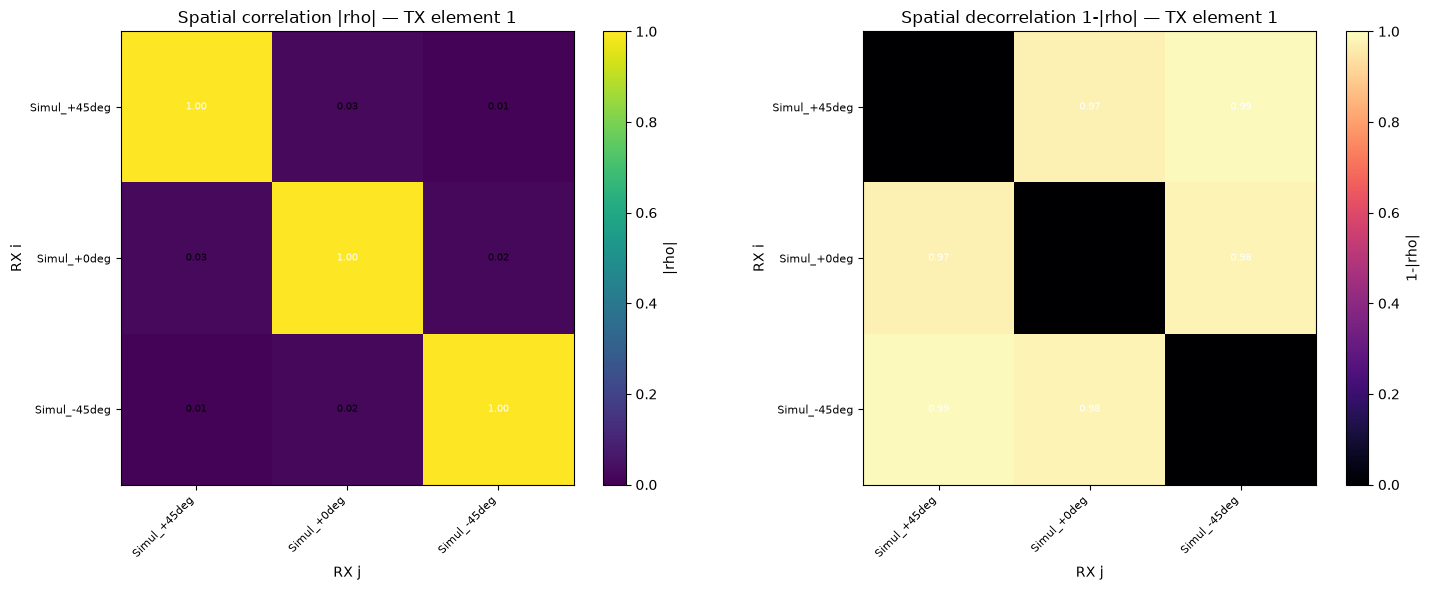

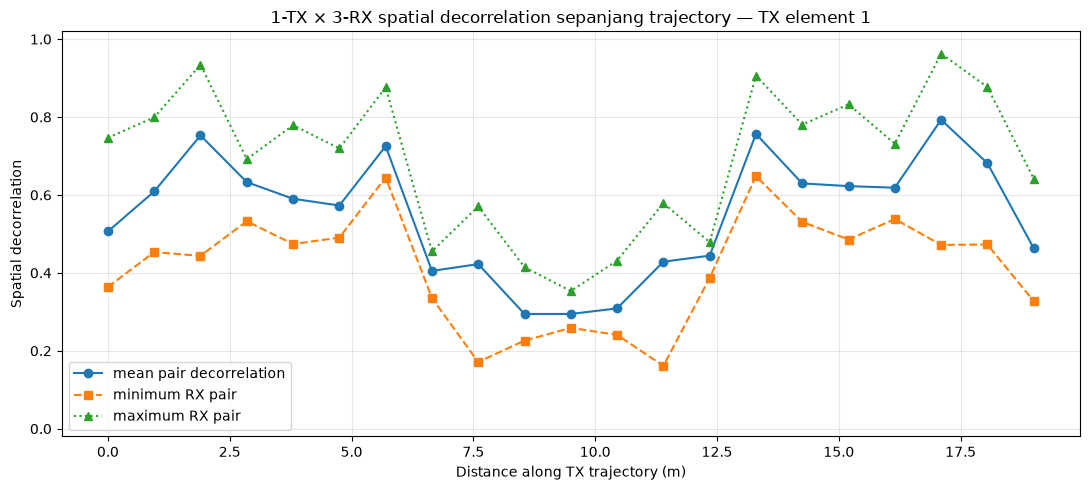

In [32]:
def plot_matrix_with_values(ax, matrix, labels, title, cmap, vmin=0.0, vmax=1.0):
    image = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(labels)), labels, fontsize=8)
    ax.set_xlabel("RX j"); ax.set_ylabel("RX i"); ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if np.isfinite(matrix[i, j]):
                text_color = "white" if matrix[i, j] > 0.55 else "black"
                ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                        fontsize=7, color=text_color)
    return image


if spatial_correlation_overall.size:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    im0 = plot_matrix_with_values(
        axes[0], spatial_correlation_overall, rx_labels,
        f"Spatial correlation |rho| — TX element {SPATIAL_DECORR_TX_INDEX}", "viridis")
    im1 = plot_matrix_with_values(
        axes[1], spatial_decorrelation_overall, rx_labels,
        f"Spatial decorrelation 1-|rho| — TX element {SPATIAL_DECORR_TX_INDEX}", "magma")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, label="|rho|")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, label="1-|rho|")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(spatial_decorrelation_trajectory["distance_along_m"],
            spatial_decorrelation_trajectory["mean_spatial_decorrelation"],
            color="tab:blue", marker="o", label="mean pair decorrelation")
    ax.plot(spatial_decorrelation_trajectory["distance_along_m"],
            spatial_decorrelation_trajectory["min_pair_decorrelation"],
            color="tab:orange", marker="s", linestyle="--", label="minimum RX pair")
    ax.plot(spatial_decorrelation_trajectory["distance_along_m"],
            spatial_decorrelation_trajectory["max_pair_decorrelation"],
            color="tab:green", marker="^", linestyle=":", label="maximum RX pair")
    ax.set(xlabel="Distance along TX trajectory (m)", ylabel="Spatial decorrelation",
           title=f"1-TX × 3-RX spatial decorrelation sepanjang trajectory — "
                 f"TX element {SPATIAL_DECORR_TX_INDEX}", ylim=(-0.02, 1.02))
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

### Interpretasi spatial decorrelation

- Gunakan **mean off-diagonal decorrelation** sebagai ringkasan seluruh pasangan RX; diagonal
  tidak ikut dihitung.
- Nilai mendekati `1` menunjukkan respons kanal kompleks antar-RX semakin berbeda.
- Nilai mendekati `0` menunjukkan respons antar-RX sangat mirip dan potensi diversity spasialnya
  rendah.
- Kurva minimum menunjukkan pasangan RX yang paling berkorelasi pada suatu waypoint; kurva
  maksimum menunjukkan pasangan yang paling terdekorlasi.
- Ubah `SPATIAL_DECORR_TX_INDEX` untuk menguji elemen TX lain. Jangan merata-ratakan kanal kompleks
  dari 3 TX sebelum korelasi karena phase cancellation dapat mengubah interpretasi.

- Evaluasi ini memerlukan `MOBILITY_NUM_TIME_STEPS >= 2`. Bila hanya satu time sample tersedia,
  cell akan berhenti dengan error agar hasil snapshot tidak keliru disebut mobility-based spatial
  decorrelation.
- `MOBILITY_SAMPLING_FREQUENCY_HZ` harus cukup tinggi untuk menyampel perubahan fase akibat
  Doppler tanpa temporal aliasing.

## 13. Spatial decorrelation tanpa normalisasi energi channel

Bagian ini memakai CFR mobility asli dari `trajectory_H_time_all` tanpa membagi setiap vektor
channel dengan norma energinya. Dua besaran dilaporkan.

**Raw spatial cross-correlation power**:

$$
G_{ij}=\left|\frac{1}{N}\sum_{n=1}^{N}h_i[n]h_j^*[n]\right|.
$$

Faktor $1/N$ hanya membentuk sample mean agar hasil tidak berubah ketika jumlah sampel berubah;
tidak ada pembagian dengan $\|\mathbf h_i\|_2$ atau $\|\mathbf h_j\|_2$. Karena itu $G_{ij}$
masih memuat pengaruh absolute channel gain/path loss.

Untuk ukuran ketidakmiripan/dekorelasi raw digunakan **mean channel-difference power**:

$$
Q_{ij}=\frac{1}{N}\sum_{n=1}^{N}|h_i[n]-h_j[n]|^2.
$$

$Q_{ij}=0$ berarti kedua channel identik. Semakin besar $Q_{ij}$, semakin berbeda channel kompleks
kedua RX, tetapi nilainya **tidak dibatasi pada 0–1**. Oleh sebab itu `1-G` tidak digunakan karena
secara matematis tidak valid untuk cross-correlation yang tidak dinormalisasi.

Seperti Section 12, realization per waypoint adalah $n=(t,f)$ dan keseluruhan trajectory adalah
$n=(w,t,f)$. Magnitude dan fase dari CFR mobility Sionna RT sama-sama dipertahankan.

In [33]:
def raw_spatial_matrices(H_rx_samples):
    """Raw cross-correlation and difference power; no per-channel energy normalization."""
    H = np.asarray(H_rx_samples, dtype=complex)
    if H.ndim != 2:
        raise ValueError(f"Expected H [n_rx, n_realizations], received {H.shape}")
    n_samples = H.shape[1]
    if n_samples == 0:
        raise ValueError("At least one channel realization is required.")

    # G_ij = |E[h_i h_j*]|. Division by N is sample averaging, not channel normalization.
    raw_cross_correlation = np.abs(H @ H.conj().T) / n_samples

    # Q_ij = E[|h_i-h_j|^2], computed without materializing [rx,rx,n_samples].
    mean_power = np.mean(np.abs(H) ** 2, axis=1)
    complex_cross_mean = (H @ H.conj().T) / n_samples
    raw_difference_power = (mean_power[:, None] + mean_power[None, :]
                            - 2.0 * np.real(complex_cross_mean))
    raw_difference_power = np.maximum(raw_difference_power, 0.0)
    np.fill_diagonal(raw_difference_power, 0.0)
    return raw_cross_correlation, raw_difference_power


def mean_unique_pairs(matrix):
    matrix = np.asarray(matrix, float)
    return np.mean(matrix[np.triu_indices(matrix.shape[0], k=1)])


raw_spatial_cross_correlation_overall = np.empty((0, 0))
raw_spatial_difference_power_overall = np.empty((0, 0))
raw_spatial_decorrelation_trajectory = pd.DataFrame()

if trajectory_H_time_all:
    first_shape = np.asarray(trajectory_H_time_all[0]).shape
    if len(first_shape) != 4 or first_shape[2] < 2:
        raise ValueError(
            "Expected native mobility CFR [rx, tx, time, frequency] with time >= 2; "
            f"received {first_shape}")

    raw_overall_realizations = []
    raw_rows = []
    for waypoint, H_waypoint_time in enumerate(trajectory_H_time_all):
        H_one_tx = np.asarray(H_waypoint_time)[:, SPATIAL_DECORR_TX_INDEX, :, :]
        H_rx_samples = H_one_tx.reshape(H_one_tx.shape[0], -1)
        G_wp, Q_wp = raw_spatial_matrices(H_rx_samples)
        raw_overall_realizations.append(H_rx_samples)

        wp_result = trajectory_results[trajectory_results["waypoint"] == waypoint].iloc[0]
        upper = np.triu_indices(Q_wp.shape[0], k=1)
        raw_rows.append({
            "waypoint": waypoint,
            "distance_along_m": wp_result["distance_along_m"],
            "time_s": wp_result["time_s"],
            "mean_raw_cross_correlation": mean_unique_pairs(G_wp),
            "mean_raw_difference_power": mean_unique_pairs(Q_wp),
            "min_raw_difference_power": np.min(Q_wp[upper]),
            "max_raw_difference_power": np.max(Q_wp[upper]),
        })

    H_raw_overall = np.concatenate(raw_overall_realizations, axis=1)
    (raw_spatial_cross_correlation_overall,
     raw_spatial_difference_power_overall) = raw_spatial_matrices(H_raw_overall)
    raw_spatial_decorrelation_trajectory = pd.DataFrame(raw_rows)

    print("=" * 72)
    print("UNNORMALIZED SPATIAL CHANNEL EVALUATION — 1 TX x 3 RX")
    print("=" * 72)
    print(f"Selected TX element                    : {SPATIAL_DECORR_TX_INDEX}")
    print(f"Realizations per RX (waypoint*time*freq): {H_raw_overall.shape[1]}")
    print(f"Mean raw off-diagonal |E[h_i h_j*]|    : "
          f"{mean_unique_pairs(raw_spatial_cross_correlation_overall):.6e}")
    print(f"Mean raw off-diagonal E[|h_i-h_j|^2]   : "
          f"{mean_unique_pairs(raw_spatial_difference_power_overall):.6e}")
    print("\nPer-waypoint raw summary:")
    print(raw_spatial_decorrelation_trajectory.to_string(index=False))
else:
    print("trajectory_H_time_all kosong. Jalankan Section 11 terlebih dahulu.")

raw_spatial_decorrelation_trajectory

UNNORMALIZED SPATIAL CHANNEL EVALUATION — 1 TX x 3 RX
Selected TX element                    : 1
Realizations per RX (waypoint*time*freq): 134736
Mean raw off-diagonal |E[h_i h_j*]|    : 4.722607e-10
Mean raw off-diagonal E[|h_i-h_j|^2]   : 4.863357e-08

Per-waypoint raw summary:
 waypoint  distance_along_m  time_s  mean_raw_cross_correlation  mean_raw_difference_power  min_raw_difference_power  max_raw_difference_power
        0              0.00    0.00                2.211881e-09               2.055364e-08              2.114439e-09              3.515074e-08
        1              0.95    0.95                2.056322e-09               2.764852e-08              2.236224e-09              4.467000e-08
        2              1.90    1.90                2.135613e-09               3.929397e-08              2.715358e-09              6.288013e-08
        3              2.85    2.85                3.013036e-09               5.539124e-08              2.578996e-09              8.891411e-08
    

,waypoint,distance_along_m,time_s,mean_raw_cross_correlation,mean_raw_difference_power,min_raw_difference_power,max_raw_difference_power
0,0,0.00,0.00,2.211881e-09,2.055364e-08,2.114439e-09,3.515074e-08
1,1,0.95,0.95,2.056322e-09,2.764852e-08,2.236224e-09,4.467000e-08
2,2,1.90,1.90,2.135613e-09,3.929397e-08,2.715358e-09,6.288013e-08
3,3,2.85,2.85,3.013036e-09,5.539124e-08,2.578996e-09,8.891411e-08
4,4,3.80,3.80,4.713146e-09,5.827770e-08,5.648336e-09,9.343650e-08
5,5,4.75,4.75,3.625924e-09,4.187975e-08,4.306898e-09,6.660717e-08
6,6,5.70,5.70,1.352197e-09,1.252204e-08,4.839966e-09,1.949725e-08
7,7,6.65,6.65,3.002115e-09,1.086863e-08,4.303541e-09,1.672918e-08
8,8,7.60,7.60,8.497525e-09,6.556518e-08,1.105829e-08,1.189061e-07
9,9,8.55,8.55,1.332868e-08,1.311271e-07,3.747175e-09,1.960017e-07


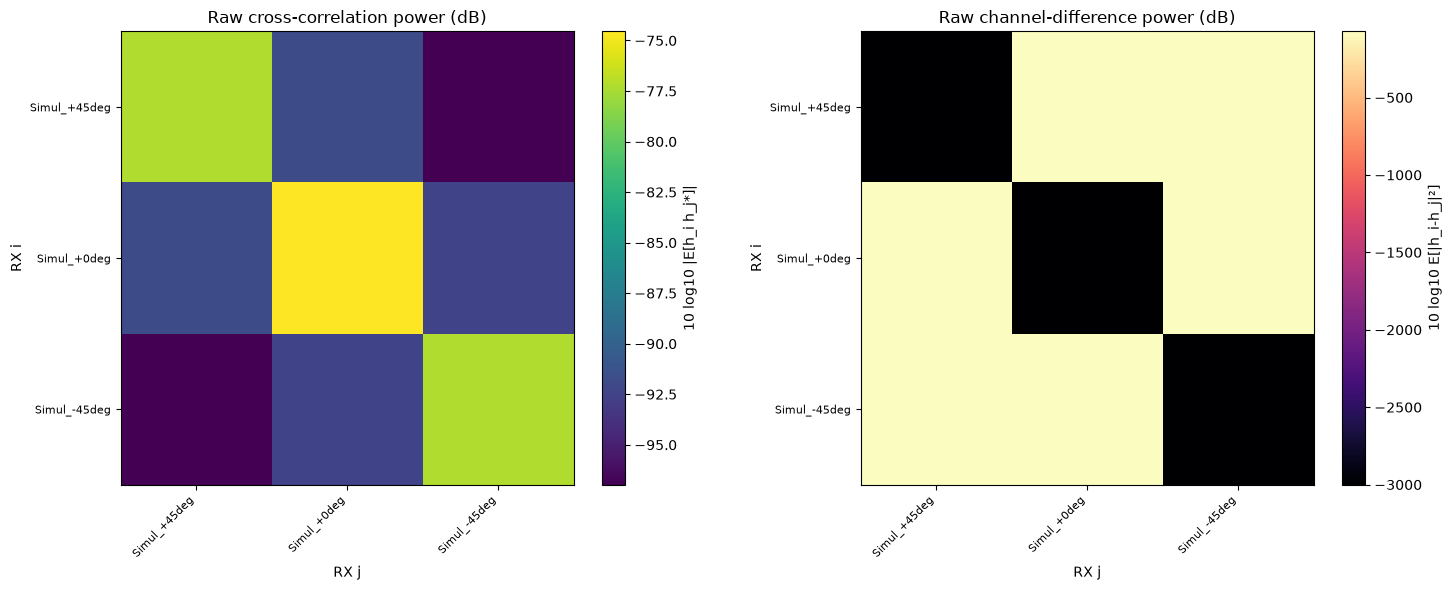

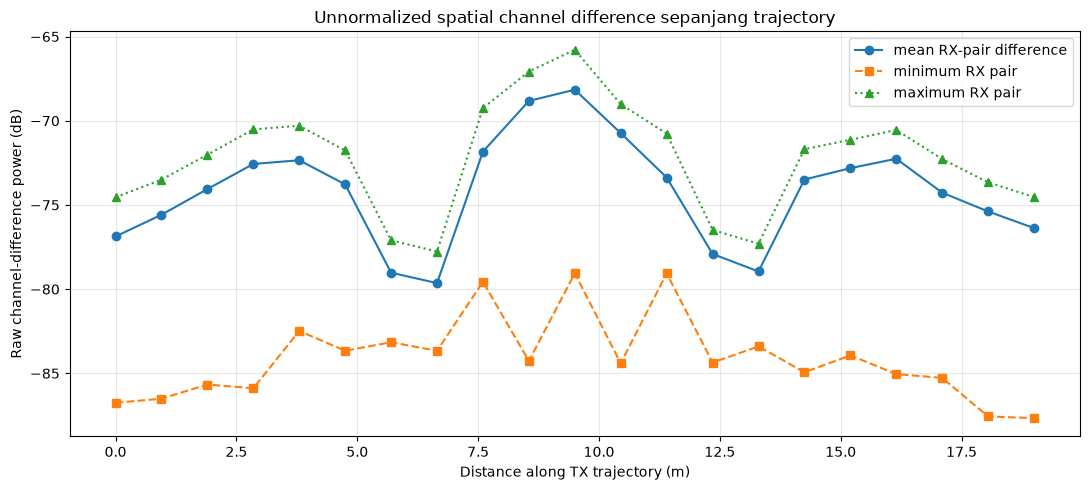

In [34]:
if raw_spatial_cross_correlation_overall.size:
    eps_plot = 1e-300
    G_db = 10 * np.log10(raw_spatial_cross_correlation_overall + eps_plot)
    Q_db = 10 * np.log10(raw_spatial_difference_power_overall + eps_plot)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    im0 = axes[0].imshow(G_db, cmap="viridis")
    im1 = axes[1].imshow(Q_db, cmap="magma")
    for ax, title in zip(axes, ["Raw cross-correlation power (dB)",
                                "Raw channel-difference power (dB)"]):
        ax.set_xticks(range(len(rx_labels)), rx_labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(rx_labels)), rx_labels, fontsize=8)
        ax.set(xlabel="RX j", ylabel="RX i", title=title)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, label="10 log10 |E[h_i h_j*]|")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, label="10 log10 E[|h_i-h_j|²]")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    x = raw_spatial_decorrelation_trajectory["distance_along_m"]
    ax.plot(x, 10*np.log10(raw_spatial_decorrelation_trajectory[
                "mean_raw_difference_power"] + eps_plot),
            color="tab:blue", marker="o", label="mean RX-pair difference")
    ax.plot(x, 10*np.log10(raw_spatial_decorrelation_trajectory[
                "min_raw_difference_power"] + eps_plot),
            color="tab:orange", marker="s", ls="--", label="minimum RX pair")
    ax.plot(x, 10*np.log10(raw_spatial_decorrelation_trajectory[
                "max_raw_difference_power"] + eps_plot),
            color="tab:green", marker="^", ls=":", label="maximum RX pair")
    ax.set(xlabel="Distance along TX trajectory (m)",
           ylabel="Raw channel-difference power (dB)",
           title="Unnormalized spatial channel difference sepanjang trajectory")
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

### Interpretasi hasil tanpa normalisasi

- Gunakan $G_{ij}$ untuk melihat absolute cross-channel coupling yang masih dipengaruhi path loss.
- Gunakan $Q_{ij}$ sebagai ukuran raw ketidakmiripan channel: `0` berarti identik, nilai lebih
  besar berarti lebih berbeda.
- Nilai raw tidak dapat dibandingkan langsung dengan $D_{ij}=1-|\rho_{ij}|$ pada Section 12 karena
  rentang dan skalanya berbeda.
- Perubahan $Q_{ij}$ dapat disebabkan oleh spatial signature **dan** perbedaan received power.
  Gunakan Section 12 bila tujuan evaluasi adalah kemiripan bentuk channel yang independen dari
  skala energi; gunakan Section 13 bila absolute channel gain memang ingin dipertahankan.

## 14. Median-based spatial correlation — robust terhadap outlier

Metode ini menggunakan satu elemen TX yang sama dengan Section 12, yaitu
`SPATIAL_DECORR_TX_INDEX`. Korelasi dihitung lebih dahulu pada setiap blok waypoint $w$ dan time
sample mobility $t$, menggunakan seluruh frequency sample $f=1,\ldots,N_f$:

$$
\rho_{ij}^{(w,t)}
=
\frac{
\displaystyle\sum_{f=1}^{N_f}h_i^{(w,t)}[f]\,h_j^{(w,t)*}[f]
}{
\sqrt{
\left(\displaystyle\sum_{f=1}^{N_f}|h_i^{(w,t)}[f]|^2\right)
\left(\displaystyle\sum_{f=1}^{N_f}|h_j^{(w,t)}[f]|^2\right)
}
}.
$$

Median spatial correlation keseluruhan trajectory kemudian didefinisikan sebagai

$$
C_{ij}^{\mathrm{med}}
=
\operatorname{median}_{w,t}
\left\{|\rho_{ij}^{(w,t)}|\right\},
$$

dan median spatial decorrelation adalah

$$
D_{ij}^{\mathrm{med}}=1-C_{ij}^{\mathrm{med}}.
$$

Untuk kurva pada satu waypoint, median hanya diambil terhadap time sample:

$$
C_{ij}^{\mathrm{med}}(w)
=
\operatorname{median}_{t}
\left\{|\rho_{ij}^{(w,t)}|\right\}.
$$

Median diterapkan setelah magnitude normalized correlation dihitung, bukan langsung pada bilangan
kompleks. Dengan demikian $0\le C_{ij}^{\mathrm{med}}\le1$, diagonal tetap bernilai 1, dan satu
time sample/waypoint ekstrem tidak mendominasi hasil seperti pada penggabungan seluruh sample.

In [35]:
def correlation_blocks_frequency(H_rx_time_frequency):
    """Return |rho| matrices per time block for H shaped [rx, time, frequency]."""
    H = np.asarray(H_rx_time_frequency, dtype=complex)
    if H.ndim != 3:
        raise ValueError(f"Expected H [rx, time, frequency], received {H.shape}")
    block_matrices = []
    for time_index in range(H.shape[1]):
        correlation_abs, _ = spatial_correlation_matrix(H[:, time_index, :])
        block_matrices.append(correlation_abs)
    return np.stack(block_matrices, axis=0)  # [time, rx, rx]


median_spatial_correlation_overall = np.empty((0, 0))
median_spatial_decorrelation_overall = np.empty((0, 0))
median_spatial_decorrelation_trajectory = pd.DataFrame()

if trajectory_H_time_all:
    first_shape = np.asarray(trajectory_H_time_all[0]).shape
    if len(first_shape) != 4 or first_shape[2] < 2:
        raise ValueError(
            "Median mobility correlation requires [rx, tx, time, frequency] and time >= 2; "
            f"received {first_shape}")

    all_correlation_blocks = []
    median_rows = []
    for waypoint, H_waypoint_time in enumerate(trajectory_H_time_all):
        H_one_tx = np.asarray(H_waypoint_time)[:, SPATIAL_DECORR_TX_INDEX, :, :]
        correlation_blocks = correlation_blocks_frequency(H_one_tx)
        all_correlation_blocks.append(correlation_blocks)

        correlation_median_wp = np.nanmedian(correlation_blocks, axis=0)
        decorrelation_median_wp = 1.0 - correlation_median_wp
        wp_result = trajectory_results[trajectory_results["waypoint"] == waypoint].iloc[0]
        median_rows.append({
            "waypoint": waypoint,
            "distance_along_m": wp_result["distance_along_m"],
            "time_s": wp_result["time_s"],
            "median_pair_correlation": mean_off_diagonal(correlation_median_wp),
            "median_pair_decorrelation": mean_off_diagonal(decorrelation_median_wp),
            "minimum_pair_decorrelation": np.nanmin(
                decorrelation_median_wp[np.triu_indices(
                    decorrelation_median_wp.shape[0], k=1)]),
            "maximum_pair_decorrelation": np.nanmax(
                decorrelation_median_wp[np.triu_indices(
                    decorrelation_median_wp.shape[0], k=1)]),
        })

    all_correlation_blocks = np.concatenate(all_correlation_blocks, axis=0)
    median_spatial_correlation_overall = np.nanmedian(all_correlation_blocks, axis=0)
    median_spatial_decorrelation_overall = 1.0 - median_spatial_correlation_overall
    median_spatial_decorrelation_trajectory = pd.DataFrame(median_rows)

    print("=" * 72)
    print("MEDIAN-BASED SPATIAL CORRELATION — 1 TX x 3 RX")
    print("=" * 72)
    print(f"Selected TX element                  : {SPATIAL_DECORR_TX_INDEX}")
    print(f"Correlation blocks (waypoint*time)  : {all_correlation_blocks.shape[0]}")
    print(f"Frequency samples per block         : {first_shape[3]}")
    print(f"Median overall correlation          : "
          f"{mean_off_diagonal(median_spatial_correlation_overall):.4f}")
    print(f"Median overall decorrelation        : "
          f"{mean_off_diagonal(median_spatial_decorrelation_overall):.4f}")
    print("\nPer-waypoint median summary:")
    print(median_spatial_decorrelation_trajectory.to_string(index=False))
else:
    print("trajectory_H_time_all kosong. Jalankan Section 11 terlebih dahulu.")

median_spatial_decorrelation_trajectory

MEDIAN-BASED SPATIAL CORRELATION — 1 TX x 3 RX
Selected TX element                  : 1
Correlation blocks (waypoint*time)  : 336
Frequency samples per block         : 401
Median overall correlation          : 0.4692
Median overall decorrelation        : 0.5308

Per-waypoint median summary:
 waypoint  distance_along_m  time_s  median_pair_correlation  median_pair_decorrelation  minimum_pair_decorrelation  maximum_pair_decorrelation
        0              0.00    0.00                 0.510072                   0.489928                    0.357041                    0.715594
        1              0.95    0.95                 0.424618                   0.575382                    0.460272                    0.690738
        2              1.90    1.90                 0.260363                   0.739637                    0.446489                    0.895156
        3              2.85    2.85                 0.369052                   0.630948                    0.531292                 

,waypoint,distance_along_m,time_s,median_pair_correlation,median_pair_decorrelation,minimum_pair_decorrelation,maximum_pair_decorrelation
0,0,0.00,0.00,0.510072,0.489928,0.357041,0.715594
1,1,0.95,0.95,0.424618,0.575382,0.460272,0.690738
2,2,1.90,1.90,0.260363,0.739637,0.446489,0.895156
3,3,2.85,2.85,0.369052,0.630948,0.531292,0.687430
4,4,3.80,3.80,0.410554,0.589446,0.472798,0.778593
5,5,4.75,4.75,0.427022,0.572978,0.489759,0.719622
6,6,5.70,5.70,0.272237,0.727763,0.643426,0.877494
7,7,6.65,6.65,0.595015,0.404985,0.335599,0.455072
8,8,7.60,7.60,0.577731,0.422269,0.170907,0.570659
9,9,8.55,8.55,0.705487,0.294513,0.226848,0.413893


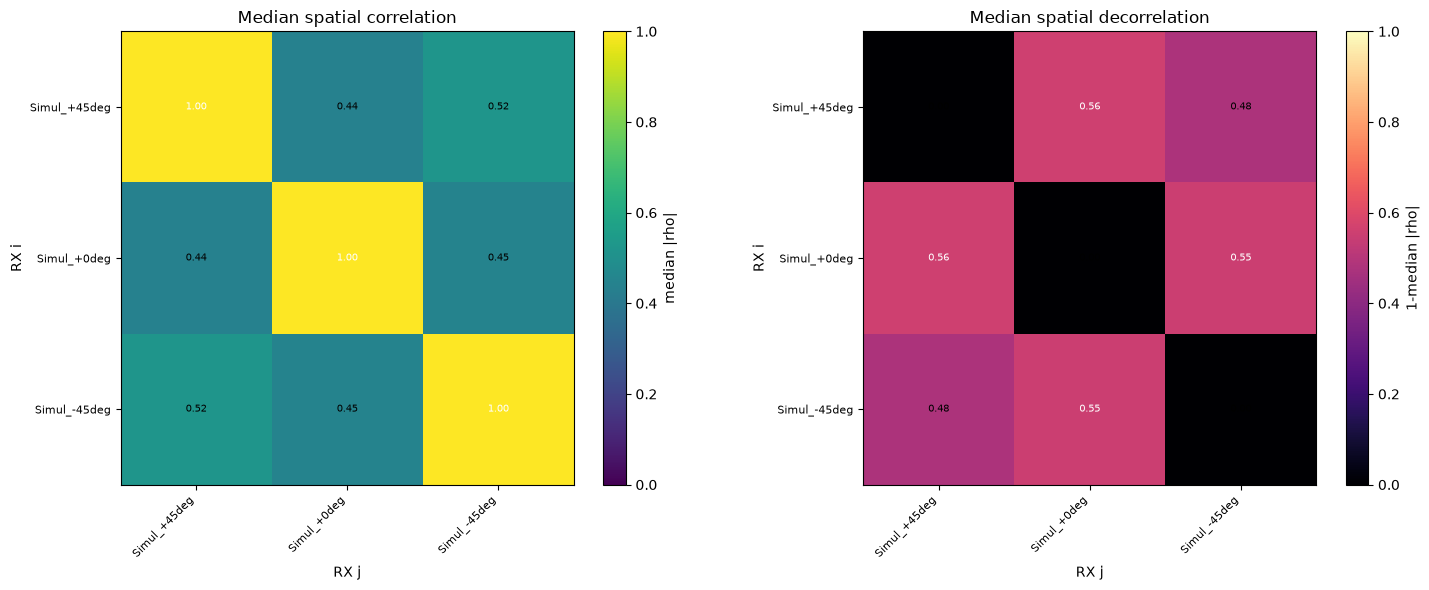

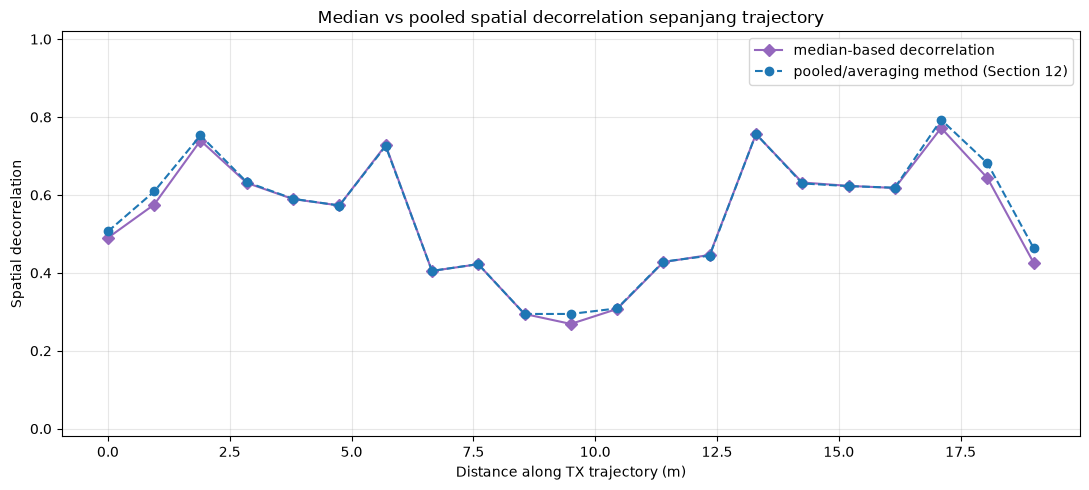

In [36]:
if median_spatial_correlation_overall.size:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    im0 = plot_matrix_with_values(
        axes[0], median_spatial_correlation_overall, rx_labels,
        "Median spatial correlation", "viridis")
    im1 = plot_matrix_with_values(
        axes[1], median_spatial_decorrelation_overall, rx_labels,
        "Median spatial decorrelation", "magma")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, label="median |rho|")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, label="1-median |rho|")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(11, 5))
    x = median_spatial_decorrelation_trajectory["distance_along_m"]
    ax.plot(x, median_spatial_decorrelation_trajectory[
                "median_pair_decorrelation"],
            color="tab:purple", marker="D", label="median-based decorrelation")
    if not spatial_decorrelation_trajectory.empty:
        ax.plot(spatial_decorrelation_trajectory["distance_along_m"],
                spatial_decorrelation_trajectory["mean_spatial_decorrelation"],
                color="tab:blue", marker="o", linestyle="--",
                label="pooled/averaging method (Section 12)")
    ax.set(xlabel="Distance along TX trajectory (m)", ylabel="Spatial decorrelation",
           title="Median vs pooled spatial decorrelation sepanjang trajectory",
           ylim=(-0.02, 1.02))
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

### Interpretasi metode median

- Median membuat hasil lebih robust terhadap deep fade, blockage singkat, atau time sample dengan
  phase/channel ekstrem.
- Hasil Section 14 adalah median dari koefisien korelasi per blok, sedangkan Section 12 menghimpun
  realization time-frequency menjadi satu vektor korelasi.
- Nilai median dan pooled/averaging tidak harus sama. Selisih besar menunjukkan distribusi
  korelasi yang skewed atau memiliki outlier.
- Setelah median matriks dihitung, ringkasan antarpasangan RX tetap memakai mean off-diagonal agar
  satu angka mewakili seluruh 3 pasangan unik. Matriks lengkap tetap menjadi hasil utama.